In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
# read metadata
meta_filename = '1876954_7680KSPS_srsRAN_Project_gnb_short.sigmf-meta'

with open(meta_filename, 'r') as f:
    meta_data = json.load(f)

In [3]:
meta_data['global']

{'core:author': 'SDRangel',
 'core:datatype': 'ci32_le',
 'core:description': 'SDRangel SigMF I/Q recording file',
 'core:hw': 'PlutoSDR',
 'core:num_channels': 1,
 'core:recorder': 'SDRangel',
 'core:sample_rate': 7680000.0,
 'core:sha512': '0bcd162b7fbcdd14b97088518cc682a26777e71a943cd7363dc917ab33b2900a91dc16ca04b0a8247468136aee28db475f1d03333bf36f47296b2264d565d869',
 'core:version': '1.2.3',
 'sdrangel:arch': 'x86_64',
 'sdrangel:os': 'Ubuntu 22.04.2 LTS',
 'sdrangel:qt_version': '5.15.3',
 'sdrangel:rx_bits': 24,
 'sdrangel:version': '7.13.0-19-g91f484445'}

In [4]:
meta_data

{'global': {'core:author': 'SDRangel',
  'core:datatype': 'ci32_le',
  'core:description': 'SDRangel SigMF I/Q recording file',
  'core:hw': 'PlutoSDR',
  'core:num_channels': 1,
  'core:recorder': 'SDRangel',
  'core:sample_rate': 7680000.0,
  'core:sha512': '0bcd162b7fbcdd14b97088518cc682a26777e71a943cd7363dc917ab33b2900a91dc16ca04b0a8247468136aee28db475f1d03333bf36f47296b2264d565d869',
  'core:version': '1.2.3',
  'sdrangel:arch': 'x86_64',
  'sdrangel:os': 'Ubuntu 22.04.2 LTS',
  'sdrangel:qt_version': '5.15.3',
  'sdrangel:rx_bits': 24,
  'sdrangel:version': '7.13.0-19-g91f484445'},
 'captures': [{'core:datetime': '2023-07-20T11:39:48.680Z',
   'core:frequency': 1876954000.0,
   'core:length': 4210688,
   'core:sample_start': 0,
   'sdrangel:sample_rate': 7680000,
   'sdrangel:tsms': 1689853188680}],
 'annotations': [{'core:freq_lower_edge': 1874074000.0,
   'core:freq_upper_edge': 1879834000.0,
   'core:generator': 'destevez Jupyter notebook',
   'core:label': 'Frame 0',
   'core

In [5]:
data_type = meta_data['global']['core:datatype']
Fs = meta_data['global']['core:sample_rate']

if data_type == 'ci32_le':
    dtype = np.int32
elif data_type == 'ci16_le':
    dtype = np.int16
elif data_type == 'ci8_le':
    dtype = np.int8
else:
    raise ValueError(f"Unsupported data type: {data_type}")

Fs

7680000.0

In [6]:
# read data
data_filename = '1876954_7680KSPS_srsRAN_Project_gnb_short.sigmf-data'

with open(data_filename, 'rb') as f:
    tmp = np.fromfile(f,dtype=dtype)  # Adjust dtype as needed

In [7]:
scale = 2**(-23)
rx = scale*tmp[0::2] + scale*1j*tmp[1::2]

In [8]:
rx.size

1100272

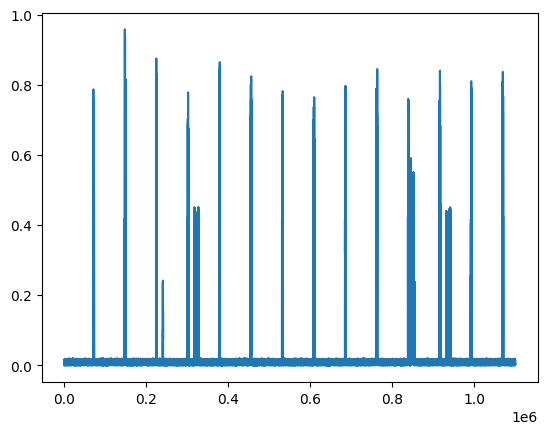

In [9]:
plt.plot(abs(rx))
plt.show()

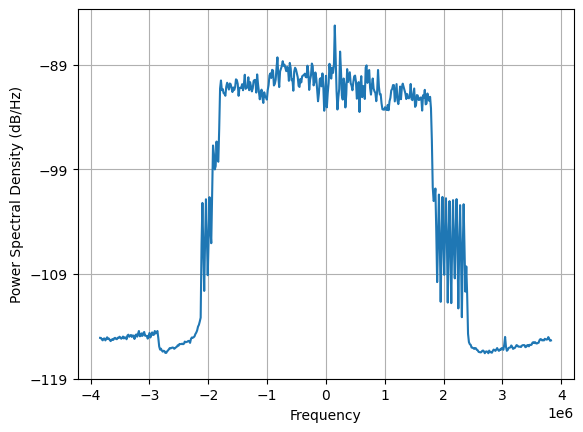

In [10]:
Pxx, ff = plt.psd(rx, Fs=Fs, NFFT=512)
plt.show()

In [11]:
rxf = rx

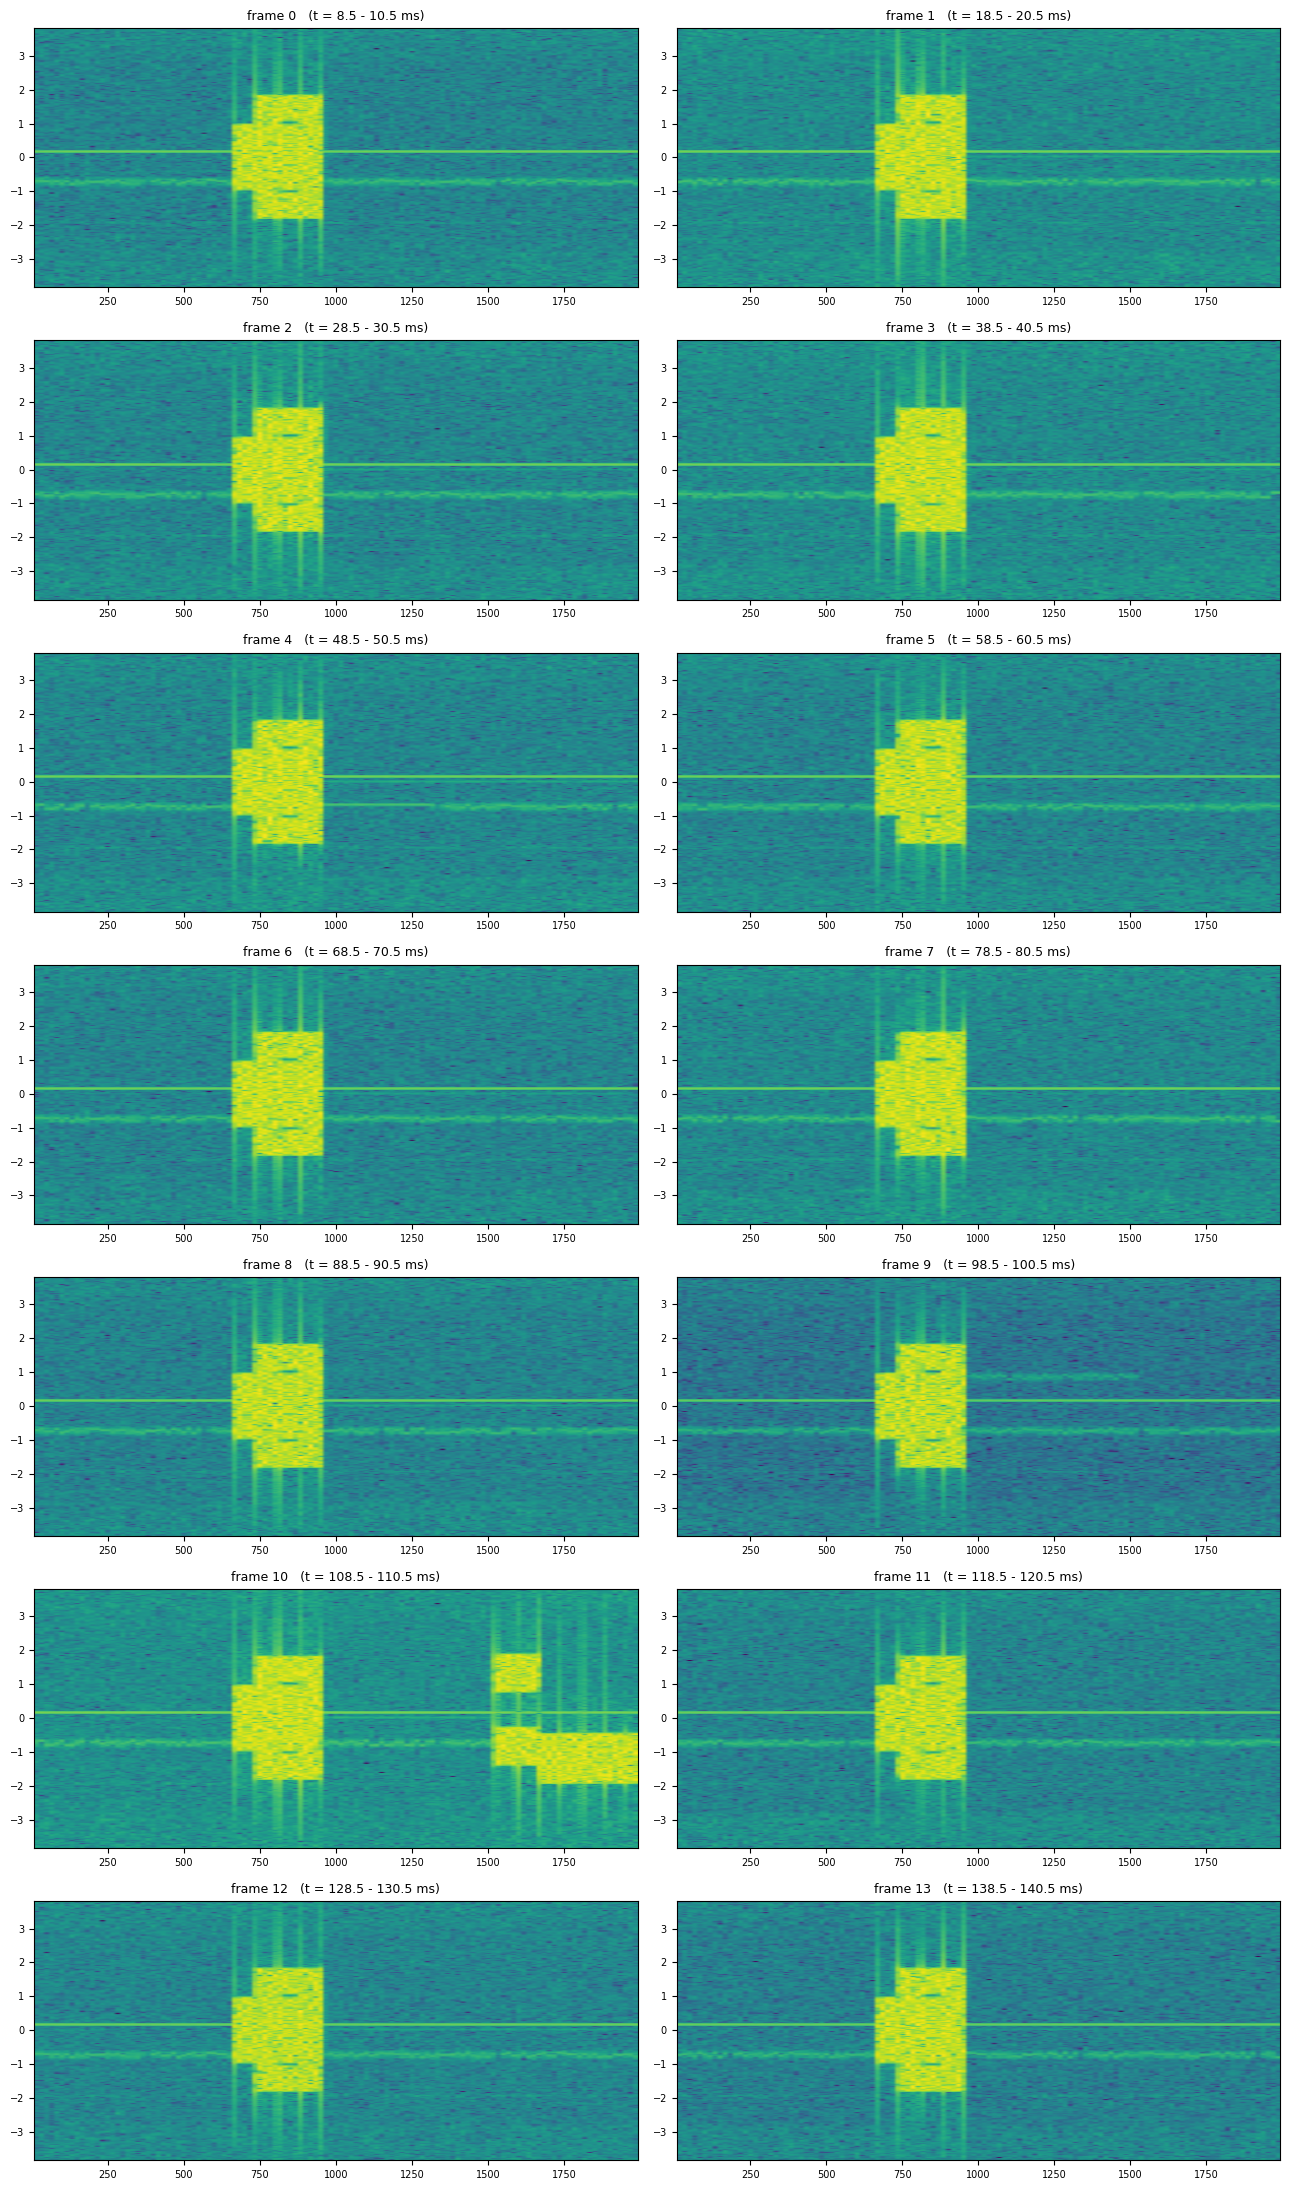

In [12]:
n_frames = 14
win_ms   = 2                                   # window length in ms
t0_ms    = 8.5                                   # window start within "frame cycle"

fig, axes = plt.subplots(7, 2, figsize=(13, 22))

for n in range(n_frames):
    ax = axes[n // 2, n % 2]
    start = int((t0_ms + 10*n) * 1e-3 * Fs)
    dur   = int(win_ms * 1e-3 * Fs)
    if start + dur > len(rxf):
        ax.set_visible(False); continue
    ax.specgram(rxf[start:start+dur], NFFT=256, noverlap=128, Fs=Fs/1e6)
    ax.set_title('frame {:d}   (t = {:.1f} - {:.1f} ms)'.format(
        n, start/Fs*1e3, (start+dur)/Fs*1e3), fontsize=9)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

In [13]:
start = int(108.5e-3 * Fs)
dur   = int(1e-3 * Fs)          

In [14]:
# system parameters
N_FFT = int(Fs//15e3)
N_CP = 36
N_CP_extra = 4

### CP

In [15]:
lag = N_FFT                                   
Lcp = N_CP                                    
prod = rxf[:-lag] * np.conj(rxf[lag:])
R = np.convolve(prod, np.ones(Lcp))

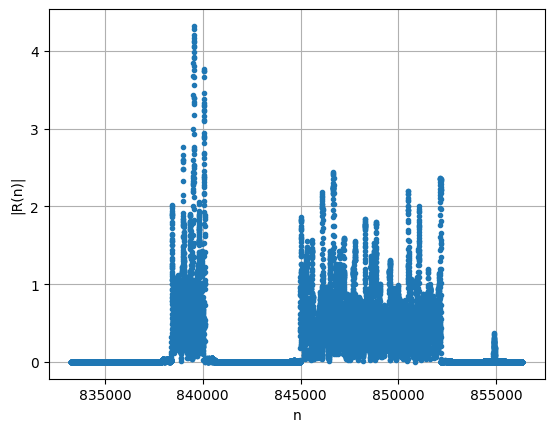

In [16]:
plt.plot(np.arange(start,start+3*dur), np.abs(R[start:start+3*dur]),'.')
plt.xlabel('n') 
plt.ylabel('|R(n)|')
plt.grid()
plt.show()

In [17]:
corr = np.abs(R[start:start+dur]).copy()

half = (N_FFT + N_CP) // 2          # erase radius = half a symbol
N_peaks = 4                          # how many to extract

locs = np.zeros(N_peaks, dtype=int)
vals = np.zeros(N_peaks)

for k in range(N_peaks):
    p = np.argmax(corr)              # strongest remaining peak
    locs[k] = p + start              # back to absolute sample index
    vals[k] = corr[p]
    corr[max(0, p-half) : p+half+1] = 0     # erase its neighborhood

# sort by position for readability
order = np.argsort(locs)
locs, vals = locs[order], vals[order]

print('locations:', locs)
print('spacings :', np.diff(locs))
print('values   :', vals)
print('angles   :', np.angle(R[locs]))

locations: [838433 838982 839531 840076]
spacings : [549 549 545]
values   : [2.02112433 2.76602896 4.32039859 3.76093867]
angles   : [-0.01016378 -0.01801406  0.00779184 -0.03266328]


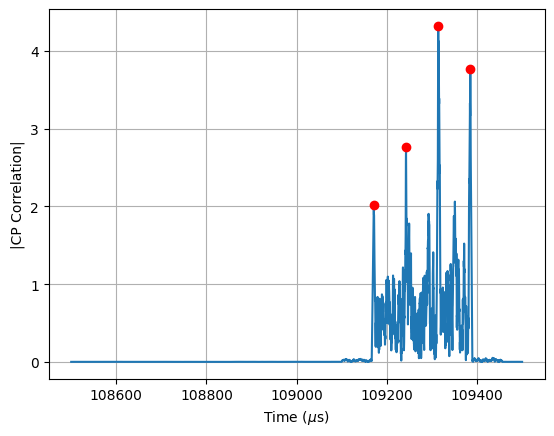

In [18]:
# plot the correlation and mark the detected peaks
mag = np.abs(R[start:start+dur])                 # fresh magnitude, not the erased copy
t_us = (np.arange(start, start+dur)) / Fs * 1e6  # absolute sample index -> microseconds

plt.plot(t_us, mag)
plt.plot(locs / Fs * 1e6, vals, 'ro')            # locs/vals from the peak loop
plt.grid()
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel('|CP Correlation|')
plt.show()

Peak at 109171.0us (sample 838433) - estimated frequency offset:  +24.26Hz
Peak at 109242.4us (sample 838982) - estimated frequency offset:  +43.01Hz
Peak at 109313.9us (sample 839531) - estimated frequency offset:  -18.60Hz
Peak at 109384.9us (sample 840076) - estimated frequency offset:  +77.98Hz
==> Average frequency offset:  +29.6Hz


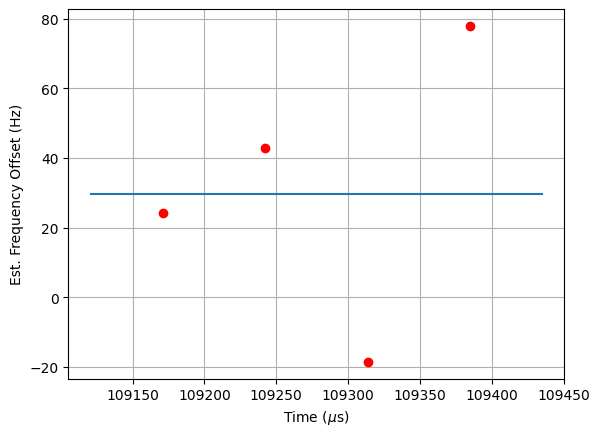

In [19]:
## Estimate the frequency offset (fractional part, from CP correlation angles)

# NOTE: corr was erased at the peaks during peak extraction -> use the original R.
df = -np.angle(R[locs]) / N_FFT / 2 / np.pi * Fs

for n in range(len(locs)):
    print('Peak at {:6.1f}us (sample {:d}) - estimated frequency offset: {:+7.2f}Hz'.format(
        locs[n]/Fs*1e6, locs[n], df[n]
    ))

# magnitude-weighted average: sum in the complex domain, then take the angle
avg_df = -np.angle(np.sum(R[locs])) / N_FFT / 2 / np.pi * Fs
print('==> Average frequency offset: {:+6.1f}Hz'.format(avg_df))

t_locs = locs / Fs * 1e6
plt.plot([t_locs[0]-50, t_locs[-1]+50], avg_df*np.ones(2))
plt.plot(t_locs, df, 'ro')
plt.grid()
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel('Est. Frequency Offset (Hz)')
plt.show()

CFO has very small effect in time domain.

### PSS
ts 7.4.2.2  Sequence generation
The sequence $d_{\text{PSS}}(n)$ for the primary synchronization signal is defined by

$$
d_{\text{PSS}}(n) = 1 - 2x(m)
$$

$$
m = \left(n + 43 N_{\text{ID}}^{(2)}\right) \bmod 127, \qquad 0 \le n < 127
$$

where

$$
x(i+7) = \left(x(i+4) + x(i)\right) \bmod 2
$$

and

$$
[x(6)\ x(5)\ x(4)\ x(3)\ x(2)\ x(1)\ x(0)] = [1\ 1\ 1\ 0\ 1\ 1\ 0]
$$
ts 7.4.3.1  Mapping to physical resources
the subcarriers numbered in increasing order from 0 to 239
56, 57, …, 182 

In [20]:
def seq_nr_pss(N_id_2):
    x = np.zeros(127, dtype=int)
    x[:7] = [0,1,1,0,1,1,1]
    for i in range(120):
        x[i+7] = x[i+4] ^ x[i]
    m = (np.arange(127) + 43*N_id_2) % 127
    return 1 - 2*x[m]          # BPSK ±1

In [21]:
def nr_pss(N_id_2,N_FFT):

    pss = seq_nr_pss(N_id_2)
    
    # mapping to resource elements
    re = np.zeros(N_FFT,complex)
    re[N_FFT//2-63:N_FFT//2+64] = pss
    
    # return time domain PSS
    return np.fft.ifft(np.fft.ifftshift(re)) 

In [22]:
seg_start = locs[0] - 2*(N_FFT + N_CP)          
seg_stop  = locs[-1] + 3*(N_FFT + N_CP)        
rx = rxf[seg_start : seg_stop]

for nid in range(3):
    pss = nr_pss(nid, N_FFT)
    pss_norm = np.linalg.norm(pss)

    corr = np.zeros(len(rx) - N_FFT)
    for i in range(len(corr)):
        seg = rx[i : i + N_FFT]
        corr[i] = np.abs(np.sum(seg * np.conj(pss))) / (np.linalg.norm(seg) * pss_norm)

    print('N_id_2 = {:d}:  max corr = {:.3f}  at sample {:d} (absolute {:d})'.format(
        nid, corr.max(), corr.argmax(), corr.argmax() + seg_start))

N_id_2 = 0:  max corr = 0.204  at sample 698 (absolute 838035)
N_id_2 = 1:  max corr = 0.247  at sample 586 (absolute 837923)
N_id_2 = 2:  max corr = 0.191  at sample 802 (absolute 838139)


CFO may be very large to let subcarrier shift.

In [23]:
seg_start = locs[0] - 2*(N_FFT + N_CP)
seg_stop  = locs[-1] + 3*(N_FFT + N_CP)
rx = rxf[seg_start : seg_stop]

nn = np.arange(len(rx))

for k in [0, +1, -1, +2, -2]:                    # integer-subcarrier hypotheses
    trial = rx * np.exp(-2j*np.pi*k*15e3*nn/Fs)   # k*SCS + fractional
    print('--- k = {:+d} ---'.format(k))

    for nid in range(3):
        pss = nr_pss(nid, N_FFT)
        pss_norm = np.linalg.norm(pss)

        corr = np.zeros(len(trial) - N_FFT)
        for i in range(len(corr)):
            seg = trial[i : i + N_FFT]
            corr[i] = np.abs(np.sum(seg * np.conj(pss))) / (np.linalg.norm(seg) * pss_norm)

        print('N_id_2 = {:d}:  max corr = {:.3f}  at sample {:d} (absolute {:d})'.format(
            nid, corr.max(), corr.argmax(), corr.argmax() + seg_start))

--- k = +0 ---
N_id_2 = 0:  max corr = 0.204  at sample 698 (absolute 838035)
N_id_2 = 1:  max corr = 0.247  at sample 586 (absolute 837923)
N_id_2 = 2:  max corr = 0.191  at sample 802 (absolute 838139)
--- k = +1 ---
N_id_2 = 0:  max corr = 0.187  at sample 838 (absolute 838175)
N_id_2 = 1:  max corr = 0.257  at sample 585 (absolute 837922)
N_id_2 = 2:  max corr = 0.178  at sample 1910 (absolute 839247)
--- k = -1 ---
N_id_2 = 0:  max corr = 0.212  at sample 818 (absolute 838155)
N_id_2 = 1:  max corr = 0.986  at sample 1098 (absolute 838435)
N_id_2 = 2:  max corr = 0.204  at sample 821 (absolute 838158)
--- k = +2 ---
N_id_2 = 0:  max corr = 0.207  at sample 897 (absolute 838234)
N_id_2 = 1:  max corr = 0.258  at sample 585 (absolute 837922)
N_id_2 = 2:  max corr = 0.187  at sample 1809 (absolute 839146)
--- k = -2 ---
N_id_2 = 0:  max corr = 0.223  at sample 1261 (absolute 838598)
N_id_2 = 1:  max corr = 0.257  at sample 586 (absolute 837923)
N_id_2 = 2:  max corr = 0.181  at sampl

In [24]:
pss_start = locs[0] + 2 # prior cp 838433, now detection 838435.
N_id_2 = 1

### SSS
ts 7.4.2.3.1  Sequence generation
The sequence $d_{\text{SSS}}(n)$ for the secondary synchronization signal is defined by

$$
d_{\text{SSS}}(n) = \left[1 - 2x_0\big((n + m_0) \bmod 127\big)\right]\left[1 - 2x_1\big((n + m_1) \bmod 127\big)\right]
$$

$$
m_0 = 15\left\lfloor \frac{N_{\text{ID}}^{(1)}}{112} \right\rfloor + 5N_{\text{ID}}^{(2)}, \qquad m_1 = N_{\text{ID}}^{(1)} \bmod 112, \qquad 0 \le n < 127
$$

where

$$
x_0(i+7) = \left(x_0(i+4) + x_0(i)\right) \bmod 2
$$

$$
x_1(i+7) = \left(x_1(i+1) + x_1(i)\right) \bmod 2
$$

and

$$
[x_0(6)\ x_0(5)\ x_0(4)\ x_0(3)\ x_0(2)\ x_0(1)\ x_0(0)] = [0\ 0\ 0\ 0\ 0\ 0\ 1]
$$

$$
[x_1(6)\ x_1(5)\ x_1(4)\ x_1(3)\ x_1(2)\ x_1(1)\ x_1(0)] = [0\ 0\ 0\ 0\ 0\ 0\ 1]
$$

with $N_{\text{ID}}^{(1)} \in \{0, 1, \dots, 335\}$.

ts 7.4.3.1  Mapping to physical resources
same as PSS: symbol 2 of the SS/PBCH block, subcarriers 56, 57, …, 182

In [25]:
def seq_nr_sss(N_id_1, N_id_2):
    x0 = np.zeros(127, dtype=int); x0[:7] = [1,0,0,0,0,0,0]   # x(0)=1, rest 0
    x1 = np.zeros(127, dtype=int); x1[:7] = [1,0,0,0,0,0,0]
    for i in range(120):
        x0[i+7] = x0[i+4] ^ x0[i]
        x1[i+7] = x1[i+1] ^ x1[i]
    m0 = 15*(N_id_1//112) + 5*N_id_2
    m1 = N_id_1 % 112
    n = np.arange(127)
    return (1 - 2*x0[(n+m0) % 127]) * (1 - 2*x1[(n+m1) % 127])

In [26]:
rxc = rxf * np.exp(-2j*np.pi*-15e3*np.arange(len(rxf))/Fs)

sss_start = pss_start + 2*(N_FFT + N_CP)         # 70437 + 2*548 = 71533

sss_sym = rxc[sss_start : sss_start + N_FFT]
SSS_f   = np.fft.fftshift(np.fft.fft(sss_sym))
sss_rx  = SSS_f[N_FFT//2-63 : N_FFT//2+64]       # middle 127 subcarriers (same mapping as PSS)
sss_rx_norm = np.linalg.norm(sss_rx)

corr_sss = np.zeros(336)
for nid1 in range(336):
    d = seq_nr_sss(nid1, N_id_2)                 # ±1 real sequence, ||d|| = sqrt(127)
    corr_sss[nid1] = np.abs(np.sum(sss_rx * d)) / (sss_rx_norm * np.sqrt(127))

N_id_1 = int(corr_sss.argmax())
PCI    = 3*N_id_1 + N_id_2
print('N_id_1 = {:d}   (corr = {:.3f})'.format(
    N_id_1, corr_sss[N_id_1]))
print('==> PCI = 3*{} + {} = {}'.format(N_id_1, N_id_2, PCI))

N_id_1 = 0   (corr = 0.985)
==> PCI = 3*0 + 1 = 1


### PBCH coding (transmit side)

ts 38.331 §6.2.2 — MIB generation (24 bits)

| Field | Bits | Content |
|---|---|---|
| CHOICE | 1 | BCCH-BCH-MessageType: mib / messageClassExtension |
| systemFrameNumber | 6 | 6 MSBs of the 10-bit SFN |
| subCarrierSpacingCommon | 1 | scs15or60 / scs30or120 (SCS for SIB1, Msg.2/4, paging) |
| ssb-SubcarrierOffset | 4 | 4 LSBs of $k_{SSB}$ |
| dmrs-TypeA-Position | 1 | pos2 / pos3 (first DM-RS symbol for PDSCH/PUSCH) |
| pdcch-ConfigSIB1 | 8 | MSB 4 bits: CORESET#0 table index; LSB 4 bits: search space table index |
| cellBarred | 1 | barred / notBarred |
| intraFreqReselection | 1 | allowed / notAllowed |
| spare | 1 | — |
| **total** | **24** | |

ts 38.212 §7.1.1 — PBCH payload generation (32 bits)

8 timing-related bits are appended to the 24-bit MIB:

| Field | Bits |
|---|---|
| 4 LSBs of SFN | 4 |
| half-frame bit $n_{hf}$ | 1 |
| MSB of $k_{SSB}$ (for $\bar L_{max} = 4$; else 3 bits of SSB index) | 1 |
| reserved | 2 |
| **total appended** | **8** |

The 32 bits are then interleaved by the fixed pattern $G(j)$ (Table 7.1.1-1).

ts 38.212 §7.1.2 — Scrambling (first scrambling)
Gold sequence, $c_{init} = N_{ID}^{cell}$, segment selected by $\nu$ = 2nd and 3rd
LSBs of SFN. The SFN LSBs and $n_{hf}$ are NOT scrambled (receiver hypothesizes them).

ts 38.212 §7.1.3 — CRC attachment
CRC24C over the 32 bits, appended: $K = 32 + 24 = 56$ bits.

ts 38.212 §7.1.4 — Channel coding
Polar code, $n_{max} = 9$: $K = 56 \rightarrow N = 2^9 = 512$ coded bits
(input interleaving $I_{IL} = 1$, reliability sequence of §5.3.1.2).

ts 38.212 §7.1.5 — Rate matching
Sub-block interleaver + circular buffer, output $E = 864$ bits ($E > N$: repetition).

ts 38.211 §7.3.3.1 — Scrambling (second scrambling)
Gold sequence, $c_{init} = N_{ID}^{cell}$, length $4 \times 864$ ($\bar L_{max} = 4$);
864-bit segment selected by $\nu$ = 2 LSBs of the SSB index.

ts 38.211 §7.3.3.2 — Modulation
QPSK: $864 / 2 = 432$ complex symbols.

ts 38.211 §7.3.3.3 — Mapping to physical resources
432 symbols → PBCH REs of the SS/PBCH block (symbol 1: 180, symbol 2 wings: 72,
symbol 3: 180), skipping DM-RS REs.

ts 38.211 §7.4.1.4 — PBCH DM-RS
144 QPSK pilots, one in every 4 PBCH subcarriers, at positions $\{0,4,8,\dots\} + v$,
$v = N_{ID}^{cell} \bmod 4$:

| Symbol | DM-RS subcarriers | Count |
|---|---|---|
| 1 | $\{0,4,\dots,236\} + v$ | 60 |
| 2 | $\{0,4,\dots,44\} + v$, $\{192,196,\dots,236\} + v$ | 24 |
| 3 | $\{0,4,\dots,236\} + v$ | 60 |
| **total** | | **144** |

Gold sequence (38.211 §5.2.1), QPSK mapped as
$r(m) = \frac{1}{\sqrt2}\big[(1-2c(2m)) + j(1-2c(2m+1))\big]$, with
$c_{init} = 2^{11}(\bar i_{SSB}+1)(\lfloor N_{ID}^{cell}/4 \rfloor + 1) + 2^6(\bar i_{SSB}+1) + (N_{ID}^{cell} \bmod 4)$.

Sanity check: PBCH occupies $240 + 96 + 240 = 576$ REs; $576/4 = 144$ DM-RS + $432$ data REs
(matches the 432 QPSK symbols in the bit budget below).

**Bit budget:** 24 (MIB) → +8 → 32 (interleave, scramble) → +CRC24C → 56
→ Polar → 512 → rate match → 864 → scramble → QPSK → 432 symbols → REs

In [27]:
def extract_OFDM_nr(ofdm_symbol, N_sc=240):
    """FFT an OFDM symbol (useful part) and return the middle N_sc subcarriers.
    NR has no DC hole: subcarriers are contiguous."""
    re = np.fft.fftshift(np.fft.fft(ofdm_symbol))
    N_FFT = len(ofdm_symbol)
    return re[N_FFT//2 - N_sc//2 : N_FFT//2 + N_sc//2]

### Why the NR receiver only sees ONE composite channel (vs. LTE)

**LTE PBCH: the receiver must resolve individual antennas.**
CRS is transmitted *un-precoded*, one separate reference grid per antenna port
(ports 0–3, offset RE positions, muting each other). The receiver estimates each
raw channel $h_p$ per port, blindly detects the antenna configuration (1/2/4 via
CRC mask), and undoes the transmit diversity (SFBC/FSTD) using all $h_p$:

$$
y = \sum_p h_p \, s_p, \qquad \text{receiver needs every } h_p \text{ and the TX scheme}
$$

**NR SS/PBCH block: one logical port, one scalar channel.**
Everything in the SSB (PSS, SSS, PBCH, its DM-RS) is transmitted on the single
antenna port 4000 (ts 38.211 §7.4.3.1). Whatever the gNB does physically —
1 antenna, or 64 antennas with beamforming weights $w_i$ — the *same* weights
multiply the DM-RS and the data. With per-antenna propagation channels $h_i$:

$$
y = \Big(\sum_i h_i w_i\Big) x + n = H_{\text{eff}}\, x + n
$$

The receiver sees only the composite scalar $H_{\text{eff}}$. Since DM-RS and
PBCH data share it, LS estimation on the DM-RS ($\hat H = Y_{\text{dmrs}}
\cdot r^*$) directly gives the channel the data experienced. Equalization is one
scalar division. The physical antenna count, the beamforming weights, even their
existence — all invisible and irrelevant ("precoding transparency").

**Consequences for this receiver:**
- No antenna-number blind detection, no SFBC decoding, no per-port CRS grids —
  the whole LTE machinery is absent by design.
- Channel estimation is per-symbol scalar LS + frequency interpolation only.
- Each symbol's common phase (NR phase compensation, residual CFO/timing) is
  absorbed into that symbol's $\hat H$ and removed by equalization for free.

**The price (paid elsewhere, not by this receiver):**
$H_{\text{eff}}$ hides the raw $h_i$, so channel-quality feedback for beamforming
needs a *separate* un-precoded measurement signal (CSI-RS) — LTE's one CRS grid
is split in NR into SSB (sync) + DM-RS (demodulation) + CSI-RS (measurement). 

| | LTE PBCH | NR PBCH |
|---|---|---|
| Reference signal | CRS, per-port, un-precoded | DM-RS, single port, precoded with data |
| Channels to estimate | $h_0 \dots h_3$ (up to 4) | one scalar $H_{\text{eff}}$ |
| TX antenna count | blindly detected (CRC mask) | invisible, irrelevant |
| MIMO decoding | SFBC/FSTD combining | none — scalar division |
| CSI acquisition | same CRS | separate CSI-RS framework |

### DMRS

In [28]:
def pbch_dmrs_in_re(N_id_cell):
    """DM-RS subcarrier indices (within SSB k=0..239) for SSB symbols 1,2,3.
    38.211 Table 7.4.1.4.2-1."""
    v = N_id_cell % 4
    idx1 = np.arange(0, 240, 4) + v                                   # 60
    idx2 = np.concatenate([np.arange(0, 48, 4), np.arange(192, 240, 4)]) + v   # 24
    idx3 = idx1.copy()                                                # 60
    return idx1, idx2, idx3

In [29]:
def c_sequence(c_init, M):
    """38.211 §5.2.1 Gold sequence (identical to LTE 36.211 §7.2)."""
    Nc = 1600
    x1 = np.zeros(Nc + M, dtype=int); x1[0] = 1
    x2 = np.zeros(Nc + M, dtype=int)
    x2[:31] = [(c_init >> i) & 1 for i in range(31)]
    for i in range(Nc + M - 31):
        x1[i+31] = x1[i+3] ^ x1[i]
        x2[i+31] = x2[i+3] ^ x2[i+2] ^ x2[i+1] ^ x2[i]
    return (x1[Nc:Nc+M] ^ x2[Nc:Nc+M])

def pbch_dmrs_seq(N_id_cell, i_ssb_bar):
    """38.211 §7.4.1.4.1: 144 QPSK pilots for one SS/PBCH block."""
    c_init = (2**11 * (i_ssb_bar + 1) * (N_id_cell // 4 + 1)
              + 2**6 * (i_ssb_bar + 1) + (N_id_cell % 4))
    c = c_sequence(c_init, 2*144)
    m = np.arange(144)
    return (1 - 2*c[2*m] + 1j*(1 - 2*c[2*m+1])) / np.sqrt(2)

In [30]:
sym_starts = [pss_start + m*(N_FFT + N_CP) for m in (1, 2, 3)]
Y = np.array([extract_OFDM_nr(rxf[s:s+N_FFT]) for s in sym_starts])   # (3, 240)

idx1, idx2, idx3 = pbch_dmrs_in_re(PCI)
dmrs_rx = np.concatenate([Y[0][idx1], Y[1][idx2], Y[2][idx3]])        # 144 REs

#   ts 38.213 §4.1: carrier <= 3 GHz => at most L_max_bar = 4 candidate
#   SS/PBCH blocks per half-frame (candidate index in {0,1,2,3}).
#   ts 38.211 §7.4.1.4.1: the PBCH DM-RS c_init depends on
#       i_ssb_bar = i_SSB + 4*n_hf,
#   where i_SSB in {0,1,2,3} = 2 LSBs of the candidate index (here the
#   full index, since L_max_bar = 4), and n_hf in {0,1} = half-frame bit.
#   => i_ssb_bar in {0,...,7}: 4 x 2 = 8 possible DM-RS sequences.
#
#   The three PBCH symbols carry different common phases (NR phase
#   compensation at the TX + the uncompensated integer-subcarrier shift),
#   so the correlation is combined non-coherently across symbols.

corr_ib = np.zeros(8)
for i_bar in range(8):
    r = pbch_dmrs_seq(PCI, i_bar)
    S1 = np.sum(Y[0][idx1] * np.conj(r[0:60]))
    S2 = np.sum(Y[1][idx2] * np.conj(r[60:84]))
    S3 = np.sum(Y[2][idx3] * np.conj(r[84:144]))
    corr_ib[i_bar] = (np.abs(S1) + np.abs(S2) + np.abs(S3)) \
                     / (np.linalg.norm(dmrs_rx) * np.linalg.norm(r))
    print('i_ssb_bar = {:d}:  corr = {:.3f}'.format(i_bar, corr_ib[i_bar]))

i_ssb_bar = int(corr_ib.argmax())
i_ssb, n_hf = i_ssb_bar % 4, i_ssb_bar // 4
print('==> i_ssb_bar = {:d}  (i_SSB = {:d}, n_hf = {:d})'.format(i_ssb_bar, i_ssb, n_hf))

i_ssb_bar = 0:  corr = 0.949
i_ssb_bar = 1:  corr = 0.229
i_ssb_bar = 2:  corr = 0.162
i_ssb_bar = 3:  corr = 0.173
i_ssb_bar = 4:  corr = 0.153
i_ssb_bar = 5:  corr = 0.182
i_ssb_bar = 6:  corr = 0.210
i_ssb_bar = 7:  corr = 0.185
==> i_ssb_bar = 0  (i_SSB = 0, n_hf = 0)


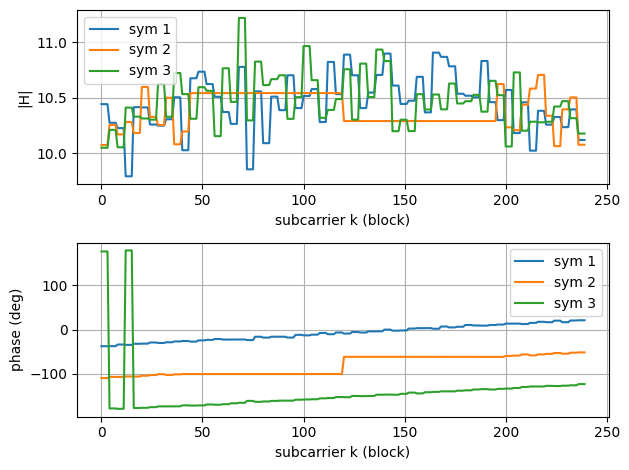

In [31]:
# PBCH channel estimation from DM-RS (per-symbol, freq interp)

r0 = pbch_dmrs_seq(PCI, i_ssb_bar)           
r_segs   = [r0[0:60],  r0[60:84], r0[84:144]]
idx_segs = [idx1,      idx2,      idx3]

H = np.zeros((3, 240), dtype=complex)
for s in range(3):
    H_pilot = Y[s][idx_segs[s]] * np.conj(r_segs[s])          
    # nearest-neighbour: each subcarrier copies the closest pilot's H
    for kk in range(240):
        n = np.argmin(np.abs(idx_segs[s] - kk))                # index of the closest pilot
        H[s, kk] = H_pilot[n]

# quick look: |H| and phase per symbol
fig, ax = plt.subplots(2,1)
for s in range(3):
    ax[0].plot(np.abs(H[s]), label=f'sym {s+1}')
    ax[1].plot(np.degrees(np.angle(H[s])), label=f'sym {s+1}')
ax[0].set_ylabel('|H|'); ax[1].set_ylabel('phase (deg)')
for a in ax: a.set_xlabel('subcarrier k (block)'); a.grid(); a.legend()
plt.tight_layout(); plt.show()

### PBCH

#### extract re

180 72 180 432


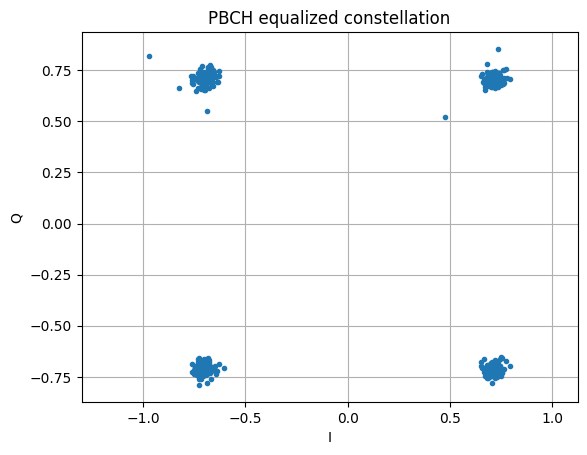

In [32]:
# boolean masks, True = data RE
mask1 = np.ones(240, dtype=bool); mask1[idx1] = False              # symbol 1: 180
mask3 = np.ones(240, dtype=bool); mask3[idx3] = False              # symbol 3: 180

mask2 = np.zeros(240, dtype=bool)
mask2[0:48] = True; mask2[192:240] = True                          # wings only
mask2[idx2] = False                                                # minus DM-RS: 72

X1 = Y[0][mask1] / H[0][mask1]
X2 = Y[1][mask2] / H[1][mask2]
X3 = Y[2][mask3] / H[2][mask3]
X  = np.concatenate([X1, X2, X3])                                  # 432, transmit order

print(len(X1), len(X2), len(X3), len(X))                           # 180 72 180 432

plt.plot(X.real, X.imag, '.')
plt.grid(); plt.axis('equal'); plt.xlabel('I'); plt.ylabel('Q')
plt.title('PBCH equalized constellation')
plt.show()

#### demod

In [33]:
# QPSK soft demodulation
#
# ts 38.211 §5.1.3 QPSK mapping:
#   x = [(1-2b(2i)) + j(1-2b(2i+1))] / sqrt(2)
# => bit 2i   lives in Re{x}:  b=0 -> +, b=1 -> -
#    bit 2i+1 lives in Im{x}

llr = np.zeros(2*len(X))
llr[0::2] = X.real          # even bits from I
llr[1::2] = X.imag          # odd bits from Q

#### 2nd descrambling

In [34]:
# descrambling (2nd scrambling, ts 38.211 §7.3.3.1)
#
# TX: b_scr(i) = ( b(i) + c(i + nu*E) ) mod 2,  E = 864
#   c: Gold sequence, c_init = N_ID_cell  (= PCI)
#   sequence length 4*E for L_max_bar = 4;
#   segment selected by nu = 2 LSBs of the SSB index = i_ssb = 0

E  = 864
nu = i_ssb % 4          # 2 LSBs of SSB index; = 0 here

c_scr = c_sequence(PCI, 4*E)                 # full 4*E sequence
c_seg = c_scr[nu*E : (nu+1)*E]               # our 864-bit segment

llr_d = llr * (1 - 2*c_seg)                  # sign flip where c=1

#### de-rate-matching

In [35]:
# PBCH rate recovery (ts 38.212 §7.1.5, reverse), E=864 -> N=512
#
# TX side:
#   1) sub-block interleaver (§5.4.1.1): the N=512 coded bits are split
#      into 32 sub-blocks of 16 bits; sub-blocks reordered by the fixed
#      pattern P(i) (Table 5.4.1.1-1)
#   2) circular buffer, read E=864 bits: for E > N this is REPETITION -
#      bits 0..351 of the interleaved word are sent twice
# RX side (LLR domain):
#   1) fold: y[i mod N] += llr_d[i]  (soft combining of repeated bits)
#   2) de-interleave sub-blocks

N = 512

# --- step 1: soft-combine the repetition (fold 864 into 512) ---
d_llr = np.zeros(N)
for i in range(E):
    d_llr[i % N] += llr_d[i]

# --- step 2: sub-block de-interleaver ---
# P(i), ts 38.212 Table 5.4.1.1-1 (32 entries)
P = np.array([0,1,2,4,3,5,6,7,8,16,9,17,10,18,11,19,12,20,13,21,
              14,22,15,23,24,25,26,28,27,29,30,31])

B = N // 32                                  # 16 bits per sub-block
llr_polar = np.zeros(N)
for j in range(32):                          # j-th interleaved sub-block
    llr_polar[P[j]*B : (P[j]+1)*B] = d_llr[j*B : (j+1)*B]

#### polar decoding

In [36]:
# Polar SC (successive cancellation) decoder
#
# Decodes on the same butterfly as the encoder, right to left.
# Recursion at each level (length-N problem -> two length-N/2):
#   left  child: L' = f(a,b)          conservative combine (min-sum)
#   right child: L' = g(a,b, x_left)  uses left decisions as known
# Leaf: frozen -> 0;  info -> sign of LLR  (LLR>0 <=> bit 0)
# Returns (u_hat, x_hat): decisions at input side, re-encoded bits

def polar_encode(u):
    """Polar encoding d = u * G_N over GF(2): n layers of pairwise XOR
    (left <- left XOR right), pairing distance 1,2,4,...,N/2."""
    x = u.copy()
    step = 1
    while step < len(x):
        for i in range(0, len(x), 2*step):
            for j in range(i, i+step):
                x[j] ^= x[j+step]
        step *= 2
    return x

def f_op(a, b):                       # both halves unknown: bottleneck rule
    return np.sign(a) * np.sign(b) * np.minimum(np.abs(a), np.abs(b))

def g_op(a, b, x_left):               # left half decided: full combine
    return b + (1 - 2*x_left) * a

def polar_decode(llr, pos, frozen):
    N = len(llr)
    if N == 1:                        # leaf: decide one u-bit
        if frozen[pos]:
            u = 0                     # frozen position: known to be 0
        else:
            u = 0 if llr[0] >= 0 else 1
        return np.array([u]), np.array([u])
    h = N // 2
    a, b = llr[:h], llr[h:]
    u_l, x_l = polar_decode(f_op(a, b),      pos,     frozen)
    u_r, x_r = polar_decode(g_op(a, b, x_l), pos + h, frozen)
    return np.concatenate([u_l, u_r]), np.concatenate([x_l ^ x_r, x_r])

In [37]:
# ts 38.212 Table 5.3.1.2-1: polar reliability sequence, W (least to most reliable)
# part 1/2 (indices 0..511 of the table)
Q_1024_p1 = [
0,1,2,4,8,16,32,3,5,64,9,6,17,10,18,128,12,33,65,20,256,34,24,36,7,129,66,512,11,40,68,130,
19,13,48,14,72,257,21,132,35,258,26,513,80,37,25,22,136,260,264,38,514,96,67,41,144,28,69,42,
516,49,74,272,160,520,288,528,192,544,70,44,131,81,50,73,15,320,133,52,23,134,384,76,137,82,56,27,
97,39,259,84,138,145,261,29,43,98,515,88,140,30,146,71,262,265,161,576,45,100,640,51,148,46,75,266,
273,517,104,162,53,193,152,77,164,768,268,274,518,54,83,57,521,112,135,78,289,194,85,276,522,58,168,139,
99,86,60,280,89,290,529,524,196,141,101,147,176,142,530,321,31,200,90,545,292,322,532,263,149,102,105,304,
296,163,92,47,267,385,546,324,208,386,150,153,165,106,55,328,536,577,548,113,154,79,269,108,578,224,166,519,
552,195,270,641,523,275,580,291,59,169,560,114,277,156,87,197,116,170,61,531,525,642,281,278,526,177,293,388,
91,584,769,198,172,120,201,336,62,282,143,103,178,294,93,644,202,592,323,392,297,770,107,180,151,209,284,648,
94,204,298,400,608,352,325,533,155,210,305,547,300,109,184,534,537,115,167,225,326,306,772,157,656,329,110,117,
212,171,776,330,226,549,538,387,308,216,416,271,279,158,337,550,672,118,332,579,540,389,173,121,553,199,784,179,
228,338,312,704,390,174,554,581,393,283,122,448,353,561,203,63,340,394,527,582,556,181,295,285,232,124,205,182,
643,562,286,585,299,354,211,401,185,396,344,586,645,593,535,240,206,95,327,564,800,402,356,307,301,417,213,568,
832,588,186,646,404,227,896,594,418,302,649,771,360,539,111,331,214,309,188,449,217,408,609,596,551,650,229,159,
420,310,541,773,610,657,333,119,600,339,218,368,652,230,391,313,450,542,334,233,555,774,175,123,658,612,341,777,
220,314,424,395,673,583,355,287,183,234,125,557,660,616,342,316,241,778,563,345,452,397,403,207,674,558,785,432,
357,187,236,664,624,587,780,705,126,242,565,398,346,456,358,405,303,569,244,595,189,566,676,361,706,589,215,786,
647,348,419,406,464,680,801,362,590,409,570,788,597,572,219,311,708,598,601,651,421,792,802,611,602,410,231,688,
653,248,369,190,364,654,659,335,480,315,221,370,613,422,425,451,614,543,235,412,343,372,775,317,222,426,453,237,
559,833,804,712,834,661,808,779,617,604,433,720,816,836,347,897,243,662,454,318,675,618,898,781,376,428,665,736,
567,840,625,238,359,457,399,787,591,678,434,677,349,245,458,666,620,363,127,191,782,407,436,626,571,465,681,246,
707,350,599,668,790,460,249,682,573,411,803,789,709,365,440,628,689,374,423,466,793,250,371,481,574,413,603,366,
468,655,900,805,615,684,710,429,794,252,373,605,848,690,713,632,482,806,427,904]

In [38]:
# part 2/2
Q_1024_p2 = [
414,223,663,692,835,619,472,455,796,809,714,721,837,716,864,810,606,912,722,696,377,435,817,319,621,812,484,430,
838,667,488,239,378,459,622,627,437,380,818,461,496,669,679,724,841,629,351,467,438,737,251,462,442,441,469,247,
683,842,738,899,670,783,849,820,728,928,791,367,901,630,685,844,633,711,253,691,824,902,686,740,850,375,444,470,
483,415,485,905,795,473,634,744,852,960,865,693,797,906,715,807,474,636,694,254,717,575,913,798,811,379,697,431,
607,489,866,723,486,908,718,813,476,856,839,725,698,914,752,868,819,814,439,929,490,623,671,739,916,463,843,381,
497,930,821,726,961,872,492,631,729,700,443,741,845,920,382,822,851,730,498,880,742,445,471,635,932,687,903,825,
500,846,745,826,732,446,962,936,475,853,867,637,907,487,695,746,828,753,854,857,504,799,255,964,909,719,477,915,
638,748,944,869,491,699,754,858,478,968,383,910,815,976,870,917,727,493,873,701,931,756,860,499,731,823,922,874,
918,502,933,743,760,881,494,702,921,501,876,847,992,447,733,827,934,882,937,963,747,505,855,924,734,829,965,938,
884,506,749,945,966,755,859,940,830,911,871,639,888,479,946,750,969,508,861,757,970,919,875,862,758,948,977,923,
972,761,877,952,495,703,935,978,883,762,503,925,878,735,993,885,939,994,980,926,764,941,967,886,831,947,507,889,
984,751,942,996,971,890,509,949,973,1000,892,950,863,759,1008,510,979,953,763,974,954,879,981,982,927,995,765,956,
887,985,997,986,943,891,998,766,511,988,1001,951,1002,893,975,894,1009,955,1004,1010,957,983,958,987,1012,999,1016,767,989,
1003,990,1005,959,1011,1013,895,1006,1014,1017,1018,991,1020,1007,1015,1019,1021,1022,1023]

In [39]:
Q_1024 = np.array(Q_1024_p1 + Q_1024_p2)
assert len(Q_1024) == 1024 and len(set(Q_1024.tolist())) == 1024   # sanity

# info/frozen sets for PBCH: N=512, K=56 (32 payload + 24 CRC), no PC bits
Q_N512     = Q_1024[Q_1024 < 512]        # reliability order restricted to N=512
info_pos   = np.sort(Q_N512[-56:])       # 56 most reliable -> information bits
frozen_pos = np.sort(Q_N512[:-56])       # the rest -> frozen (0)
print(len(info_pos), len(frozen_pos))    # 56 456

56 456


In [40]:
# test
frozen = np.ones(512, dtype=bool)
frozen[info_pos] = False

rng = np.random.default_rng(0)
c_test = rng.integers(0, 2, 56)                  # random 56-bit "payload"
u_tx = np.zeros(512, dtype=int)
u_tx[info_pos] = c_test
d_tx = polar_encode(u_tx)                        # your 3-loop butterfly

llr_test = (1.0 - 2.0*d_tx)                      # perfect LLRs: bit0->+1, bit1->-1
u_hat, _ = polar_decode(llr_test, 0, frozen)
print('self-test:', 'PASS' if np.array_equal(u_hat[info_pos], c_test) else 'FAIL')

# ---- the real thing ----
u_hat, _ = polar_decode(llr_polar, 0, frozen)       # llr_polar from rate recovery
c_prime_hat = u_hat[info_pos].astype(int)        # 56 bits (still Pi-interleaved)
print('decoded 56 bits:', c_prime_hat)

self-test: PASS
decoded 56 bits: [0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1
 0 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1 0 0 1]


In [41]:
# ts 38.212 Table 5.3.1.1-1: interleaver pattern Pi_max (K_IL_max = 164)
Pi_max = [0,2,4,7,9,14,19,20,24,25,26,28,31,34,42,45,49,50,51,53,54,56,58,59,
61,62,65,66,67,69,70,71,72,76,77,81,82,83,87,88,89,91,93,95,98,101,104,106,
108,110,111,113,115,118,119,120,122,123,126,127,129,132,134,138,139,140,1,3,
5,8,10,15,21,27,29,32,35,43,46,52,55,57,60,63,68,73,78,84,90,92,94,96,99,
102,105,107,109,112,114,116,121,124,128,130,133,135,141,6,11,16,22,30,33,36,
44,47,64,74,79,85,97,100,103,117,125,131,136,142,12,17,23,37,48,75,80,86,
137,143,13,18,38,144,39,145,40,146,41,147,148,149,150,151,152,153,154,155,
156,157,158,159,160,161,162,163]

K = 56
offset = 164 - K
Pi = np.array([p - offset for p in Pi_max if p >= offset])   # length 56

# TX: c_prime[k] = c[Pi[k]]  ->  RX: put it back
c_hat = np.zeros(K, dtype=int)
c_hat[Pi] = c_prime_hat          # de-interleave

payload_bits = c_hat[:32]        # 32-bit PBCH payload (still 1st-scrambled!)
crc_bits     = c_hat[32:]        # 24-bit CRC24C

#### crc

In [42]:
def crc24c(bits):
    """CRC24C, poly 0x1B2B117 (D^24+D^23+D^21+D^20+D^17+D^15+D^13+D^12+D^8+D^4+D^2+D+1)."""
    poly = 0x1B2B117
    reg = 0
    for b in bits:
        reg = ((reg << 1) | int(b)) & 0x1FFFFFF
        if reg >> 24:
            reg ^= poly
    for _ in range(24):                      # flush
        reg = (reg << 1) & 0x1FFFFFF
        if reg >> 24:
            reg ^= poly
    return np.array([(reg >> (23-i)) & 1 for i in range(24)])

crc_calc = crc24c(c_hat[:32])
print('CRC check:', 'PASS' if np.array_equal(crc_calc, crc_bits) else 'FAIL')

CRC check: PASS


#### 1st descrambling

In [43]:
# 1st descrambling (ts 38.212 §7.1.2, reverse)
#
# TX scrambled M = A-3 = 29 of the 32 bits, Gold sequence with
# c_init = N_ID_cell. The 3 timing bits (SFN 3rd LSB, SFN 2nd LSB,
# half-frame bit) are NOT scrambled; nu = (SFN 3rd, SFN 2nd) LSBs,
# readable in plaintext -> no hypothesis needed.
# payload_bits is still in interleaved order; the 3 plaintext bits
# sit at interleaved positions {24, 7, 10} (from Table 7.1.1-1).

unscr_pos = {6, 24, 0}                                       
sfn_3rd, sfn_2nd = int(payload_bits[6]), int(payload_bits[24]) 
nu = 2*sfn_3rd + sfn_2nd                # scrambling segment, read directly

M  = 29
c1 = c_sequence(PCI, 4*M)               # same Gold generator, c_init = PCI

s = np.zeros(32, dtype=int)             # scrambling word aligned to the 32 positions
j = 0
for i in range(32):
    if i not in unscr_pos:
        s[i] = c1[nu*M + j]
        j += 1

a_prime = payload_bits ^ s              # descrambled, still in interleaved order
print('nu =', nu)
print('a_prime =', a_prime)

G = np.array([16,23,18,17,8,30,10,6,24,7,0,5,3,2,1,4,9,11,12,13,
              14,15,19,20,21,22,25,26,27,28,29,31])

slots = np.zeros(32, dtype=int)
for j in range(32):
    slots[j] = a_prime[G[j]] 

nu = 0
a_prime = [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0]


#### read MIB

In [44]:
# --- reassemble natural-order payload a[0..31] ---
# a = [ 24-bit MIB | 4 SFN LSBs | n_hf | kssb_MSB | 2 reserved ]
# MIB(24) = CHOICE, SFN 6 MSBs, scs, kssb 4 LSBs, dmrsTypeA, pdcchCfg(8), barred, ifr, spare
sfn_bits  = slots[0:10]                 # SFN MSB..LSB (10 bits)
n_hf_rx   = int(slots[10])
kssb_msb  = int(slots[11])
reserved  = slots[12:14]
rest      = slots[14:32]                # CHOICE, scs, kssb4, dmrsTypeA, pdcchCfg8, barred, ifr, spare

CHOICE    = int(rest[0])
scs       = int(rest[1])
kssb_lsb4 = rest[2:6]
dmrsA     = int(rest[6])
pdcchCfg  = rest[7:15]
barred    = int(rest[15])
ifr       = int(rest[16])
spare     = int(rest[17])

tobin = lambda b: int(''.join(str(int(x)) for x in b), 2)
SFN = tobin(sfn_bits)

print('CHOICE   =', CHOICE, '(expect 0)')
print('SFN      =', SFN, '   (3rd/2nd LSB vs nu={}: {})'.format(
    nu, 'OK' if (2*((SFN>>2)&1) + ((SFN>>1)&1))==nu else 'MISMATCH'))
print('n_hf     =', n_hf_rx, '(DMRS said {})'.format(n_hf))
print('scsCommon=', '15/60 kHz' if scs==0 else '30/120 kHz')
print('k_SSB    =', (kssb_msb<<4) | tobin(kssb_lsb4))
print('dmrs-TypeA-Position =', 'pos2' if dmrsA==0 else 'pos3')
print('pdcch-ConfigSIB1    =', tobin(pdcchCfg),
      '(CORESET0 idx {}, searchSpace idx {})'.format(tobin(pdcchCfg[:4]), tobin(pdcchCfg[4:])))
print('cellBarred =', barred, '  intraFreqReselection =', ifr, '  spare =', spare)
print('reserved =', reserved, '(expect [0 0])')

CHOICE   = 0 (expect 0)
SFN      = 896    (3rd/2nd LSB vs nu=0: OK)
n_hf     = 0 (DMRS said 0)
scsCommon= 15/60 kHz
k_SSB    = 8
dmrs-TypeA-Position = pos2
pdcch-ConfigSIB1    = 0 (CORESET0 idx 0, searchSpace idx 0)
cellBarred = 1   intraFreqReselection = 1   spare = 0
reserved = [0 0] (expect [0 0])


## From MIB to SIB1

### What the MIB (SFN 896, frame @ ~109 ms) has given us

| Field | Value | What it unlocks |
|---|---|---|
| SFN = 896, $n_{hf}$ = 0 | frame-level timing | this SSB sits in symbol 2, subframe 0, of frame 896 → frame start ≈ sample 837299 |
| $k_{SSB}$ = 8 | grid translation | common RB grid origin = SSB bin − 8: CORESET#0 addresses (official grid) ↔ our FFT bins |
| pdcch-ConfigSIB1 = 0/0 | CORESET#0 idx 0 → ts 38.213 Table 13-1: **24 RB × 2 symbols, offset 0 RB** | the PDCCH "parking lot": bins 128…415, 2 symbols |
| | searchSpace idx 0 → Table 13-11: **slots $n_0$, $n_0{+}1$, symbols 0–1** ($n_0 = 0$ here) | *when* to look: two candidate monitoring occasions per frame |
| scsCommon = 15/60 kHz | numerology for SIB1 path | CORESET#0 / PDCCH / PDSCH all at 15 kHz — same FFT size 512, same symbol grid |
| dmrs-TypeA-Position = pos2 | PDSCH DM-RS location | needed when equalizing the SIB1 PDSCH |
| cellBarred = notBarred | cell is open | (informational for us) |

### The remaining chain (bootstrap: each stage addresses the next)

1. **Locate PDCCH**: extract CORESET#0 (2 symbols × 288 subcarriers, bins 128–415)
   at the two candidate slots (slot 0 @ frame start, slot 1 @ +7680 samples ≈ 110.0 ms);
   the occupied one shows energy + PDCCH DM-RS comb (1 pilot per 4 subcarriers).
   Expect: *two disjoint frequency blocks* (interleaved CCE-to-REG mapping).
2. **Decode PDCCH → DCI 1_0**: DM-RS (Gold, $c_{init}$ from ts 38.211 §7.4.1.3.1) →
   channel estimate → equalize → QPSK LLRs → descramble → rate recovery →
   **polar decode (same decoder, K = DCI size + 24)** → CRC scrambled by
   **SI-RNTI = 0xFFFF** (the CRC-mask *is* the addressing).
3. **Read the DCI**: frequency-domain RB allocation, time-domain allocation
   (row index into ts 38.214 Table 5.1.2.1.1-2), MCS → the PDSCH coordinates of SIB1.
4. **Decode PDSCH → SIB1**: DM-RS (pos2 + additional) → equalize →
   **LDPC decode (ts 38.212 §5.3.2 — the last new decoder)** → transport block →
   **ASN.1 (asn1tools) → SIB1 plaintext**. End of the road.


### Where in TIME is the PDCCH? (Type0-PDCCH CSS, searchSpaceZero = 0)

**The rule — ts 38.213 clause 13, prose preceding Table 13-11** (search for
"For the SS/PBCH block with index"); original sentence, transcribed:

> "For the SS/PBCH block with index $i$, the UE determines an index of slot
> $n_0 = \left(O \cdot 2^\mu + \lfloor i \cdot M \rfloor\right) \bmod N_{slot}^{frame,\mu}$
> located in a system frame with system frame number $SFN_C$ satisfying
> $SFN_C \bmod 2 = 0$ if
> $\lfloor (O \cdot 2^\mu + \lfloor i \cdot M \rfloor) / N_{slot}^{frame,\mu} \rfloor \bmod 2 = 0$,
> or [...] $SFN_C \bmod 2 = 1$ if [...] $= 1$. The UE monitors PDCCH in the
> Type0-PDCCH CSS set over two consecutive slots starting from slot $n_0$."

with $(O, M, \text{first symbol})$ given by **Table 13-11**, row = searchSpaceZero.

**Restated as three rules**, with $T = O \cdot 2^\mu + \lfloor i \cdot M \rfloor$
("the slot count to wait, measured from an even-frame head"):

1. starting slot: $\;n_0 = T \bmod N_{slot}^{frame,\mu}$
2. frame parity: $\;SFN_C \bmod 2 = \lfloor T / N_{slot}^{frame,\mu} \rfloor \bmod 2$
3. window: slots $\{n_0,\, n_0{+}1\}$, from the first-symbol index in the table,
   lasting $N_{symb}^{CORESET}$ symbols

**Plugging in our numbers** (Table 13-11 row 0: $O=0$, $M=1$, first symbol 0;
$i = i_{SSB} = 0$, $15*2^\mu=15 \Rightarrow \mu = 0$, $N_{slot}^{frame} = 10$, $N_{symb}^{CORESET} = 2$):

$T = 0 \Rightarrow n_0 = 0$; parity $= 0 \Rightarrow$ **even SFN only**
(SFN 896 qualifies ✓); window = **slots 0 and 1, symbols 0–1**.

**Candidate windows in sample coordinates** (frame 896 start ≈ 837299;
symbol 0 carries the long CP = 40, slot = 7680 samples):

| candidate | slot | symbols | window start (sample) | note |
|---|---|---|---|---|
| A | 0 | 0–1 | 837299 | ≈ 109.0 ms |
| B | 1 | 0–1 | 837299 + 7680 = **844979** | ≈ 110.0 ms — right place from the spectrogram" |

Expected verdict: **B occupied, A empty** (srsRAN scheduled SIB1 in slot 1 of
this frame). Landmine reminder: the PDCCH's first symbol is a slot-symbol-0
→ its CP is **40, not 36** (first appearance of the long CP in our sample
arithmetic; the SSB always lived on symbols 2–5).

### PDCCH coding (transmit side)

ts 38.212 §7.3.1 — DCI 1_0 payload (SI-RNTI case)
Fields for a SIB1 grant: frequency-domain RA ($\lceil \log_2(N_{RB}(N_{RB}{+}1)/2) \rceil$
bits), time-domain RA (4), VRB-to-PRB mapping (1), MCS (5), RV (2),
SI indicator (1), reserved (15) — payload size depends on CORESET#0 width
($N_{RB} = 24 \Rightarrow$ FDRA = 9 bits $\Rightarrow$ **A = 37 bits** total... verify
against 38.212 Table 7.3.1.2.1-1 when parsing).

ts 38.212 §7.3.2 — CRC attachment
CRC24C over the payload; **the last 16 CRC bits are scrambled (XOR) with the
RNTI** — for SIB1: **SI-RNTI = 0xFFFF**. The CRC mask *is* the addressing:
only a UE trying the right RNTI sees the CRC pass. $K = A + 24$.

ts 38.212 §7.3.3 — Channel coding
Polar, $n_{max} = 9$, $I_{IL} = 1$ (same input interleaver Π as PBCH).
Same reliability sequence, same everything — **our polar decoder is reused as-is**.

ts 38.212 §7.3.4 — Rate matching
Sub-block interleaver + circular buffer to E bits.
E = 108 × (aggregation level) × 2 coded bits... precisely:
one CCE = 6 REGs = 6 RB × 1 symbol = 72 REs, of which 54 are data (18 DM-RS)
$\Rightarrow$ **E = AL × 54 × 2 = 108·AL** QPSK bit... (AL ∈ {4, 8, 16} for
Type0 CSS; blind decoding tries each).

ts 38.211 §7.3.2.3 — Scrambling
Gold sequence, $c_{init} = N_{ID}^{cell}$ (for CORESET#0), length E.

ts 38.211 §7.3.2.4 — Modulation: QPSK, E/2 symbols.

ts 38.211 §7.3.2.5 + §7.3.2.2 — Mapping: CCE → REG bundles → REs of the
CORESET, with **interleaved CCE-to-REG mapping** for CORESET#0
(REG bundle size 6, interleaver rows R=2, shift $n_{shift} = N_{ID}^{cell}$)
— this is why the transmission appears as *disjoint frequency blocks*.

ts 38.211 §7.4.1.3 — PDCCH DM-RS: one pilot every 4 subcarriers (k=4m+1),
per-symbol Gold sequence, $c_{init} = (2^{17}(14 n_{slot} + l + 1)(2N_{ID}+1) + 2N_{ID}) \bmod 2^{31}$, $N_{ID} = N_{ID}^{cell}$ for CORESET#0.

**Bit budget:** DCI ~37 → +CRC24 (RNTI-masked) → ~61 → polar N=512 →
rate match E=108·AL → scramble → QPSK → CCE→REG (interleaved) → REs

### Receive chain (this notebook, reverse order)
1. extract CORESET#0 grid (2 symbols × 288 SC) at slot 1        ← next cell
2. DM-RS verify + channel estimate (per symbol)
3. blind detection: for AL ∈ {4,8,16} × candidates: de-map CCEs →
   equalize → LLRs → descramble → rate recover → polar → CRC⊕SI-RNTI
4. CRC pass ⟹ DCI 1_0 → parse → SIB1's PDSCH coordinates

#### extract re

In [45]:
def pdcch_dmrs_seq(N_id_cell, n_slot, l, n_pilots):
    """PDCCH DM-RS (ts 38.211 §7.4.1.3.1): per-symbol Gold-QPSK pilots.
    For CORESET#0: N_ID = N_id_cell (PCI); sequence taken from index 0
    (CORESET#0 starts at common RB 0, offset 0 -> no sequence offset)."""
    c_init = (2**17 * (14*n_slot + l + 1) * (2*N_id_cell + 1) + 2*N_id_cell) % 2**31
    c = c_sequence(c_init, 2*n_pilots)
    m = np.arange(n_pilots)
    return (1 - 2*c[2*m] + 1j*(1 - 2*c[2*m+1])) / np.sqrt(2)

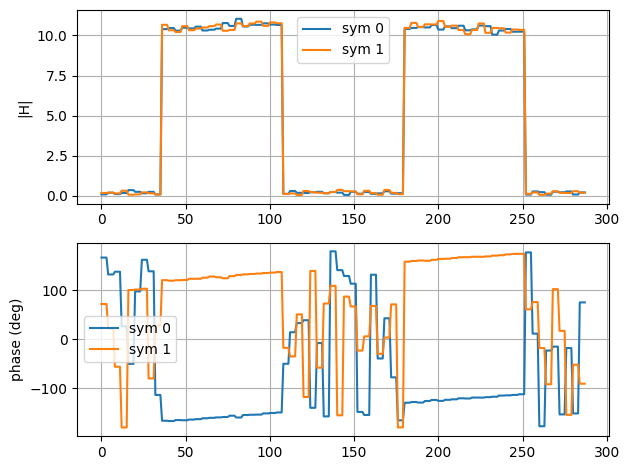

In [46]:
# ---- extract CORESET#0: slot 1, symbols 0-1 ----
pdcch_start0 = pss_start + N_FFT + 11*(N_FFT + N_CP) + N_CP_extra + (N_CP + N_CP_extra)
pdcch_start1 = pdcch_start0 + N_FFT + N_CP          # symbol 1: normal CP

Yc = np.array([
    extract_OFDM_nr(rxf[pdcch_start0 : pdcch_start0 + N_FFT], N_sc=N_FFT)[128:416],
    extract_OFDM_nr(rxf[pdcch_start1 : pdcch_start1 + N_FFT], N_sc=N_FFT)[128:416],
])    

# ---- PDCCH DM-RS: verify + channel estimate (per symbol) ----
dmrs_idx_c = np.arange(1, 288, 4)                    # k = 4m+1, 72 pilots/symbol
n_slot = 1

Hc = np.zeros((2, 288), dtype=complex)
for l in range(2):
    r = pdcch_dmrs_seq(PCI, n_slot, l, 72)           # cell from before
    y = Yc[l][dmrs_idx_c]

    H_pilot = y * np.conj(r)                          # LS at pilots
    for kk in range(288):                             # nearest-neighbour interp
        Hc[l, kk] = H_pilot[np.argmin(np.abs(dmrs_idx_c - kk))]

fig, ax = plt.subplots(2, 1)
for l in range(2):
    ax[0].plot(np.abs(Hc[l]),  label=f'sym {l}')
    ax[1].plot(np.degrees(np.angle(Hc[l])), label=f'sym {l}')
ax[0].set_ylabel('|H|'); ax[1].set_ylabel('phase (deg)')
for a in ax: a.grid(); a.legend()
plt.tight_layout(); plt.show()

#### PDCCH resource mapping: from logical CCEs to physical REs

**The pipeline (TX view):**
DCI (216 QPSK symbols for AL=4) → split into per-CCE chunks of 54 →
each CCE looks up its physical home via the interleaver → symbols written
into the data REs of that home.

**Logical vs physical:** CCE numbers {0..7} are LOGICAL labels. The
interleaver f(x) (ts 38.211 §7.3.2.2) is a fixed one-to-one permutation
assigning each logical CCE a physical REG bundle (= a solid "column" of
3 RB × 2 symbols here, since L = 6 = one CCE exactly):

  f(x) = (r·C + c + n_shift) mod (N_REG/L),  x = c·R + r
  parameters (CORESET#0, fixed by spec): L=6, R=2 ⟹ C=4, n_shift = N_ID_cell

  CCE:    0    1    2    3    4    5    6    7
  bundle: 1    5    2    6    3    7    4    0
  RBs:   3-5 15-17  6-8 18-20 9-11 21-23 12-14 0-2

**Why interleave:** frequency diversity — logically adjacent CCEs land far
apart, so one fading dip cannot kill a whole DCI. Consequence: an AL=4
transmission appears as *two disjoint frequency blocks* (CCE 0-3 ⟹
RB 3-8 ∪ 15-20 ⟹ subcarriers 36-107 ∪ 180-251 — exactly our |H| plateaus).

**RE order within a CCE** (time-first REG numbering): per RB, the 9 data
REs (skip DM-RS at k = 1,5,9) of symbol 0, then symbol 1; then next RB.

**Blind detection (Type0-CSS, 8-CCE CORESET):** the DCI sits in ONE of
3 candidates — CCE {0-3}, {4-7}, or {0-7}. Try each: de-map → equalize →
decode → CRC⊕SI-RNTI. The CRC is the judge. (Our |H| occupancy already
points to candidate {0-3}; the loop confirms it formally.)

**For our case the answer can only be AL=4, candidate {0-3}**, because the
|H| occupancy map already rules out the other two: the plateaus cover only
~half of the CORESET (~4 CCEs' worth of REs), which excludes AL=8 (it would
fill all 24 RBs); and the plateau location — RB 3-8 ∪ 15-20 — matches the
interleaved home of CCE {0,1,2,3}, not that of CCE {4,5,6,7} (RB 0-2 ∪
9-14 ∪ 21-23, exactly our valleys). 

CCE 0 -> bundle 1 -> RBs [3, 4, 5]
CCE 1 -> bundle 5 -> RBs [15, 16, 17]
CCE 2 -> bundle 2 -> RBs [6, 7, 8]
CCE 3 -> bundle 6 -> RBs [18, 19, 20]
CCE 4 -> bundle 3 -> RBs [9, 10, 11]
CCE 5 -> bundle 7 -> RBs [21, 22, 23]
CCE 6 -> bundle 4 -> RBs [12, 13, 14]
CCE 7 -> bundle 0 -> RBs [0, 1, 2]
216 QPSK symbols


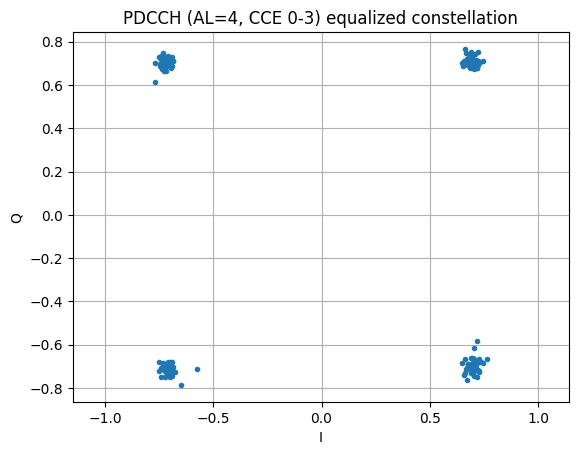

In [47]:
# PDCCH de-mapping: equalize the whole grid, then collect the
# data REs of the detected candidate (AL=4, CCE {0,1,2,3})
# in logical-CCE order via the interleaver map.
#
# ts 38.211 §7.3.2.2 - interleaved CCE-to-REG mapping, CORESET#0:
#   bundle size L = 6 REGs (= 1 CCE = 3 RB x 2 symbols here),
#   rows R = 2, C = N_bundle/R = 4, n_shift = N_ID_cell.
#   Logical CCE x lives in physical bundle f(x):
#       f(x) = (r*C + c + n_shift) mod N_bundle,   x = c*R + r
# RE order within a CCE (time-first REG numbering):
#   per RB: 9 data REs of symbol 0 (skip DM-RS k=1,5,9), then symbol 1.

# --- 1. equalize the ENTIRE CORESET grid in one shot ---
Xall = Yc / Hc                                   # (2, 288); valleys = garbage, never used

# --- 2. interleaver map: logical CCE -> physical bundle -> RBs ---
N_reg, L_b, R = 48, 6, 2
n_bund = N_reg // L_b                            # 8 bundles (= 8 CCEs here)
C      = n_bund // R                             # 4
n_shift = PCI

def f_interleave(x):
    r, c = x % R, x // R
    return (r*C + c + n_shift) % n_bund

def cce_to_rbs(cce):
    b = f_interleave(cce)
    return [3*b, 3*b+1, 3*b+2]

for cce in range(8):
    print('CCE {} -> bundle {} -> RBs {}'.format(cce, f_interleave(cce), cce_to_rbs(cce)))

# --- 3. collect data REs: FREQUENCY FIRST, THEN TIME (38.211 §7.3.2.5) ---
# The CCE/interleaver machinery only defines WHICH REs belong to the DCI;
# the symbol stream fills them in plain increasing-k, then increasing-l order.
data_off = np.array([0,2,3,4,6,7,8,10,11])       # 9 data REs per RB (skip k=1,5,9)

cce_list = [0, 1, 2, 3]                          # detected from the |H| occupancy map
occupied_rbs = sorted(sum([cce_to_rbs(c) for c in cce_list], []))   # [3..8, 15..20]

X_pdcch = []
for l in range(2):                        # time = slow index
    for rb in occupied_rbs:               # frequency = fast index
        X_pdcch.append(Xall[l, 12*rb + data_off])
X_pdcch = np.concatenate(X_pdcch)

print(len(X_pdcch), 'QPSK symbols')              # expect 216

plt.plot(X_pdcch.real, X_pdcch.imag, '.')
plt.grid(); plt.axis('equal'); plt.xlabel('I'); plt.ylabel('Q')
plt.title('PDCCH (AL=4, CCE 0-3) equalized constellation')
plt.show()

#### demod

In [48]:
llr_pdcch = np.zeros(2 * len(X_pdcch))
llr_pdcch[0::2] = X_pdcch.real
llr_pdcch[1::2] = X_pdcch.imag

#### descrambling

In [49]:
c_pd = c_sequence(PCI, len(llr_pdcch))          # E = 432 bits from the head
llr_pd = llr_pdcch * (1 - 2*c_pd)               # sign flip where c=1

#### de-rate-matching

In [50]:
# PDCCH rate recovery (ts 38.212 §5.4.1, reverse), E=432 -> N=512
#
# TX side (§5.4.1.2):
#   1) sub-block interleaver P(i) on the N=512 coded bits (same as PBCH)
#   2) circular buffer, read E bits:
#      - PBCH had E=864 > N: repetition (wrap around)
#      - here E=432 < N and K/E = 61/432 <= 7/16  => PUNCTURING:
#        the E bits are read starting from position N-E = 80,
#        i.e. coded bits 0..79 (of the interleaved word) are NEVER SENT.
# RX side (LLR domain):
#   1) place the E received LLRs at positions N-E .. N-1;
#      positions 0..79: LLR = 0  (no evidence - honest bookkeeping)
#   2) sub-block de-interleave (same P table as PBCH)

N = 512
E = len(llr_pd)                                  # 432
U = N - E                                        # 80 punctured bits

# --- step 1: undo the circular-buffer read (puncturing branch) ---
d_llr = np.zeros(N)
d_llr[U:] = llr_pd                               # e(k) = y(k+N-E): sent bits
                                                 # d_llr[0:80] stays 0

# --- step 2: sub-block de-interleaver (P from the PBCH chapter) ---
B = N // 32                                      # 16
llr_polar_pd = np.zeros(N)
for j in range(32):
    llr_polar_pd[P[j]*B : (P[j]+1)*B] = d_llr[j*B : (j+1)*B]

print('E={}, punctured={}, N={}'.format(E, U, N))

E=432, punctured=80, N=512


#### polar decoding

In [51]:
# PDCCH polar decoding: same SC decoder, new info set (K=61)
#   K = A + 24 = 37 + 24  (DCI 1_0 size for CORESET#0 N_RB=24;
#   A=37 to be pinned down against ts 38.212 §7.3.1.2.1 when parsing)

K_pd = 61
info_pos_pd   = np.sort(Q_N512[-K_pd:])
frozen_pd     = np.ones(512, dtype=bool)
frozen_pd[info_pos_pd] = False

u_hat_pd, _ = polar_decode(llr_polar_pd, 0, frozen_pd)
c_hat_pd = u_hat_pd[info_pos_pd].astype(int)         # 61 bits, still Pi-interleaved

print(len(c_hat_pd), 'bits:', c_hat_pd)

61 bits: [1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 1 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 1 1 0 0 1 0 0]


#### crc

In [52]:
# PDCCH: Pi de-interleave + CRC24C check with SI-RNTI mask
#
# ts 38.212 §7.3.2: the DCI CRC's LAST 16 BITS are XORed with the
# RNTI at the TX. For SIB1: SI-RNTI = 0xFFFF (ts 38.321: fixed value)
# => un-mask before comparing. The mask IS the addressing: trying a
# wrong RNTI makes the CRC fail.

# --- Pi de-interleave (same Pi_max table, offset for K=61) ---
K_pd = 61
offset = 164 - K_pd
Pi_pd = np.array([p - offset for p in Pi_max if p >= offset])   # length 61

c_full = np.zeros(K_pd, dtype=int)
c_full[Pi_pd] = c_hat_pd

dci_bits = c_full[:37]                     # A = 37 (to be confirmed by this very CRC)
crc_rx   = c_full[37:]                     # 24 bits

# --- CRC with SI-RNTI unmasking ---
SI_RNTI = 0xFFFF
crc_calc = crc24c(np.concatenate([np.ones(24, dtype=int), dci_bits]))

mask = np.zeros(24, dtype=int)
mask[8:] = [(SI_RNTI >> (15-i)) & 1 for i in range(16)]   # last 16 bits
crc_expected = crc_calc ^ mask

print('CRC check:', 'PASS' if np.array_equal(crc_expected, crc_rx) else 'FAIL')

CRC check: PASS


#### read DCI

In [53]:
# DCI format 1_0 (SI-RNTI) parsing — ts 38.212 §7.3.1.2.1
# Fields: FDRA(9 for N_RB=24) | TDRA(4) | VRB-PRB(1) | MCS(5) |
#         RV(2) | SI-indicator(1) | reserved(15)   = 37 bits

b = dci_bits
tob = lambda x: int(''.join(map(str, x)), 2)

FDRA = tob(b[0:9]);  TDRA = tob(b[9:13]); vrb  = int(b[13])
MCS  = tob(b[14:19]); RV  = tob(b[19:21]); SIi = int(b[21])
rsvd = b[22:37]

# --- FDRA: resource allocation type 1, RIV decode (38.214 §5.1.2.2.2) ---
N_BWP = 24
a_, b_ = FDRA // N_BWP, FDRA % N_BWP
if a_ + b_ + 1 <= N_BWP:
    L_RBs, RB_start = a_ + 1, b_
else:
    L_RBs, RB_start = N_BWP - a_ + 1, N_BWP - 1 - b_

print('FDRA (RIV)      =', FDRA, '->  RB_start =', RB_start, ', L_RBs =', L_RBs)
print('TDRA row index  =', TDRA, '+1 -> Table 5.1.2.1.1-2 (expect K0=0, S=2, L=12)')
print('VRB-to-PRB      =', vrb, '(0 = non-interleaved)')
print('MCS             =', MCS, '(Table 5.1.3.1-1: expect QPSK, R=0.37 if 5)')
print('RV              =', RV)
print('SI indicator    =', SIi, '(0 = SIB1)')
print('reserved        =', rsvd, '(expect all 0)')

FDRA (RIV)      = 168 ->  RB_start = 0 , L_RBs = 8
TDRA row index  = 0 +1 -> Table 5.1.2.1.1-2 (expect K0=0, S=2, L=12)
VRB-to-PRB      = 0 (0 = non-interleaved)
MCS             = 5 (Table 5.1.3.1-1: expect QPSK, R=0.37 if 5)
RV              = 0
SI indicator    = 0 (0 = SIB1)
reserved        = [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] (expect all 0)


## From DCI to SIB1 

### What the DCI 1_0 told us — SIB1's delivery note

| Field | Value | Meaning for us |
|---|---|---|
| FDRA (RIV=168) | RB_start=0, L_RBs=8 | frequency: common-grid RBs 0–7 = **bins 128–223** (96 SC); lower edge 8 SC below the SSB |
| TDRA (row 1) | K₀=0, S=2, L=12 | time: **same slot** (slot 1), **symbols 2–13** (12 symbols, right after the PDCCH) |
| MCS = 5 | QPSK, R ≈ 0.37 | demod: QPSK (reused); payload ≈ E·R ≈ 640 bits ≈ 80 bytes; LDPC base graph **BG2** |
| RV = 0 | redundancy version 0 | LDPC rate matching reads the circular buffer from the start (simplest case) |
| VRB-to-PRB = 0 | non-interleaved | virtual RB = physical RB: no extra map to undo |
| SI indicator = 0 | this is SIB1 | (not another SI message) |

Sample coordinates (anchored on pss_start): PDSCH symbol 2 CP start =
pdcch_start1 + N_FFT = 846115 − 36 ... = **846079**; useful starts follow the
per-symbol walk, with the **long CP (40) on slot-symbol 7** in the middle of
the allocation — the usual landmine.

### The receive chain (one new decoder, everything else reused)

1. **Extract**: 12 symbols × 96 subcarriers (bins 128–224) → Y grid (12, 96)
2. **PDSCH DM-RS** (ts 38.211 §7.4.1.1): dmrs-TypeA-Position = pos2 →
   first DM-RS at symbol 2; L=12 ⟹ 2 additional positions (Daniel: 3 DM-RS
   symbols total, 9 data symbols). Type 1 comb (density 1/2 on DM-RS symbols),
   per-symbol Gold, new c_init formula → verify + channel estimate
3. **Equalize → QPSK LLRs → descramble** (c_init = n_RNTI·2¹⁵ + n_ID —
   check §7.3.1.1: for SIB1, n_RNTI = SI-RNTI, n_ID = N_ID_cell) — all reused
4. **LDPC decode** (ts 38.212 §5.2.2 / §5.3.2) — **the last new machine**:
   TBS computation (§38.214 5.1.3.2) → base graph 2 → lifting size Z →
   parity-check matrix from the base-graph table → rate recovery (RV=0) →
   normalized min-sum / belief propagation → CRC16/24 on the transport block
5. **ASN.1 parse** (asn1tools + 38.331 SIB1 definition) → **SIB1 plaintext**:
   cell selection info, SIB scheduling, serving cell config — the end of the road

### PDSCH / DL-SCH coding (transmit side) — the SIB1 transport

**ts 38.214 §5.1.3.2 — Transport block size (TBS)**
Both sides compute the same TBS from the DCI (never signalled directly).
N_RE counts ONLY data REs: DM-RS symbols are excluded ENTIRELY — both
combs — because DCI 1_0 implies "DM-RS CDM groups without data = 2":
N_RE = 9 data symbols · 8 RB · 12 SC = **864**
→ N_info = 864 · (379/1024) · 2 · 1 = 639.56 → n = 3 → N'_info = 632
→ next valid table entry ⟹ **TBS = A = 640 bits (80 bytes)**.
*(Errata #6: first pass subtracted only the 18 pilot REs per RB
(N_RE = 1008 → TBS = 768). The empty comb carries no data AND counts as
overhead — the heatmap had already shown us this; the TBS formula agrees.)*

**ts 38.212 §7.2.1 — TB CRC**: A = 640 ≤ 3824 ⟹ **CRC16** (zeros-init,
no mask). B = 640 + 16 = **656 bits**.

**ts 38.212 §7.2.2 — Base graph**: A ≤ 3824 and R = 0.37 ≤ 0.67 ⟹ **BG2**.

**ts 38.212 §7.2.3 — Segmentation**: B = 656 ≤ 3840 ⟹ **one code block**,
no CRC24B. K' = B = 656. K_b = 10 (since B > 640).

**ts 38.212 §5.3.2 — LDPC encoding**
LDPC = a *sparse system of XOR equations* (a block code, plain and direct):
- The code IS the parity-check matrix H: **3024 equations × 3744 bits**,
  each equation touching ~4–10 bits ("low density"). Encoding = solving
  the equations so that every XOR sums to 0.
- H is stored compressed as base graph 2 (Table 5.3.2-3): a 42×52 grid;
  each entry = empty (zero block) or a shift s = V mod Z_c applied to a
  Z×Z identity. **Z_c = smallest legal Z with 10·Z ≥ 656 ⟹ 72**
  (72 = 9·2³ ∈ set i_LS = **4** = {9,18,36,72,144,288} — read that column).
- Input K = 10·Z_c = **720**: 656 real bits + **64 filler zeros**.
- Codeword: 720 systematic + 42·72 = 3024 parity = **3744** (systematic).
- First **2·Z_c = 144 systematic bits discarded** (never sent, any RV);
  the decoder recovers them from the equations. Buffer N_cb = 50·72 =
  **3600** (mother rate 720/3600 = 1/5).

**ts 38.212 §5.4.2 — Rate matching (RV=0)**
Read E = 1728 from k_0 = 0, skipping the 64 fillers:
**512 systematic + 1216 parity**; tail ~1664 parity unsent (HARQ depot;
SIB1 never retransmits). Actual rate: 656/1728 ≈ 0.38.
Then bit interleaving (§5.4.2.2, Q_m = 2 rows): first half of the
selected bits → real parts, second half → imaginary parts
(Daniel-confirmed; undone at RX before rate recovery).

**ts 38.211 §7.3.1.1 — Scrambling**: c_init = n_RNTI·2^15 + q·2^14 + n_ID,
n_RNTI = SI-RNTI = 0xFFFF, q = 0, n_ID = N_ID_cell.
**§7.3.1.2**: QPSK, 864 symbols.  **§7.3.1.5**: freq-first then time over
8 RB × 9 data symbols, skipping DM-RS REs.

**ts 38.211 §7.4.1.1 — PDSCH DM-RS**: Type 1 / mapping A; l_0 = pos2,
l_d = 14, additionalPosition = pos2 ⟹ symbols {2,7,11} ✓heatmap; comb 1/2
even SCs, empty comb NO data ✓heatmap ⟹ E = 9·96·2 = 1728; pilots +3 dB
(β_DMRS = √2, harmless).

**Bit budget (final, Daniel-verified):**
SIB1 ASN.1 (80 B incl. padding) → +CRC16 → 656 → +64 fillers → 720
→ LDPC BG2/Z_c=72 → 3744 → puncture head 144 → buffer 3600
→ RV0 read 1728 = 512 sys + 1216 parity (skip fillers)
→ interleave (Q_m=2) → scramble (SI-RNTI) → QPSK 864
→ map into 8 RB × 9 data symbols

### Receive chain (this notebook, reverse order)
1. extract PDSCH grid (12 × 96, bins 128–224) ✓ — long CP on symbol 7
2. |Y| heatmap ✓ — DM-RS {2,7,11}, empty comb confirmed
3. DM-RS verify (corr 0.99) + channel estimate: 3 anchors, freq ZOH +
   time phase-walk (−72.7°/symbol; 6→7 long-CP anomaly −209°) ✓
4. equalize (4 corners ✓) → LLRs → descramble ✓
5. de-interleave (§5.4.2.2) + **LDPC rate recovery**: 3744-position LLR
   array — head 144 → 0, systematic 512 → measured, fillers 64 → +∞,
   parity 1216 → measured, tail → 0 ✓
6. **LDPC decode** (normalized min-sum, flooding): check nodes speak
   f-style (sign·sign·min), variable nodes g-style (evidence addition),
   excluding the recipient's own message; converged in 2 iterations —
   the 144 zero-evidence head bits recovered by their neighbours ✓
7. TB CRC16 **PASS** → strip → 640-bit transport block ✓
8. ASN.1 decode (38.331 BCCH-DL-SCH-Message, UPER) → SIB1 plaintext
   ← final step

Yp shape: (12, 96)
symbol 2 useful start: 846115 (sanity: pdcch_start1 + 548 = 846115 )


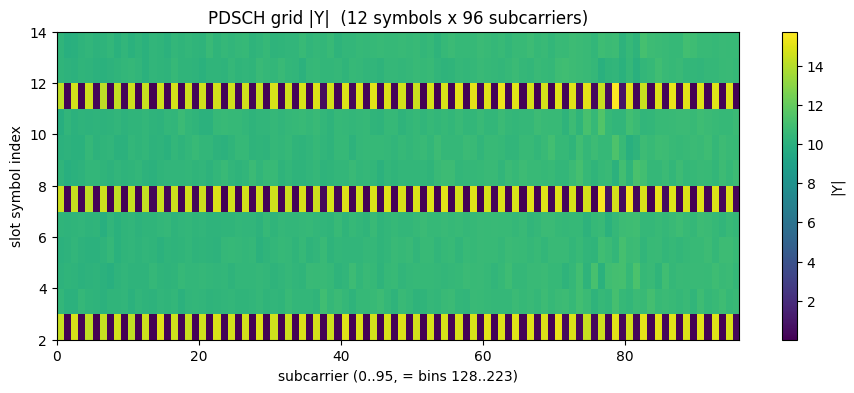

In [54]:
# PDSCH extraction: slot 1, symbols 2-13, common-grid RBs 0-7
# (bins 128..223), per the DCI: S=2, L=12, RB_start=0, L_RBs=8.
#
# Symbol walk within slot 1 (long CP on slot-symbols 0 and 7):
#   symbol 0 CP start = slot1 head; we anchor instead on the known
#   pdcch_start0 (useful part of symbol 0) and walk forward.
#   Symbols 1-6: normal CP (548 each); symbol 7: long CP (552);
#   symbols 8-13: normal again.

pdsch_syms = range(2, 14)                       # slot-symbols 2..13

# useful-part start of slot-symbol l (l >= 1), walked from pdcch_start0:
def sym_start(l):
    s = pdcch_start0                            # useful start of symbol 0
    for m in range(1, l+1):
        cp = N_CP + N_CP_extra if m == 7 else N_CP    # long CP on symbol 7
        s += N_FFT + cp
    return s

Yp = np.array([
    extract_OFDM_nr(rxf[sym_start(l) : sym_start(l) + N_FFT], N_sc=N_FFT)[128:224]
    for l in pdsch_syms
])                                              # (12, 96)

print('Yp shape:', Yp.shape)
print('symbol 2 useful start:', sym_start(2), '(sanity: pdcch_start1 + 548 =', pdcch_start1 + N_FFT + N_CP, ')')

# ---- |Y| heatmap: see the DM-RS symbols and the comb question ----
plt.figure(figsize=(11, 4))
plt.imshow(np.abs(Yp), aspect='auto', origin='lower',
           extent=[0, 96, 2, 14], interpolation='nearest')
plt.colorbar(label='|Y|')
plt.xlabel('subcarrier (0..95, = bins 128..223)')
plt.ylabel('slot symbol index')
plt.title('PDSCH grid |Y|  (12 symbols x 96 subcarriers)')
plt.show()

In [55]:
# PDSCH DM-RS sequence (ts 38.211 §7.4.1.1.1) + sentinel check
#   c_init = (2^17 (14 n_slot + l + 1)(2 N_ID + 1) + 2 N_ID + n_SCID) mod 2^31
#   N_ID = N_ID_cell, n_SCID = 0 for SIB1; per-symbol sequence.
#   Pilots on even subcarriers (config Type 1, port 1000), 48 per symbol;
#   sequence counts from CRB 0 = bin 128 -> zero offset.

def pdsch_dmrs_seq(N_id_cell, n_slot, l, n_pilots, n_scid=0):
    c_init = (2**17 * (14*n_slot + l + 1) * (2*N_id_cell + 1)
              + 2*N_id_cell + n_scid) % 2**31
    c = c_sequence(c_init, 2*n_pilots)
    m = np.arange(n_pilots)
    return (1 - 2*c[2*m] + 1j*(1 - 2*c[2*m+1])) / np.sqrt(2)

# --- sentinel: correlate each pilot symbol against its local sequence ---
dmrs_syms  = [2, 7, 11]
dmrs_idx_p = np.arange(0, 96, 2)
for s in dmrs_syms:
    r = pdsch_dmrs_seq(PCI, n_slot, s, 48)
    y = Yp[s-2][dmrs_idx_p]
    c = np.abs(np.sum(y*np.conj(r))) / (np.linalg.norm(y)*np.linalg.norm(r))
    print('symbol {:2d}: DM-RS corr = {:.3f}'.format(s, c))

symbol  2: DM-RS corr = 0.993
symbol  7: DM-RS corr = 0.992
symbol 11: DM-RS corr = 0.992


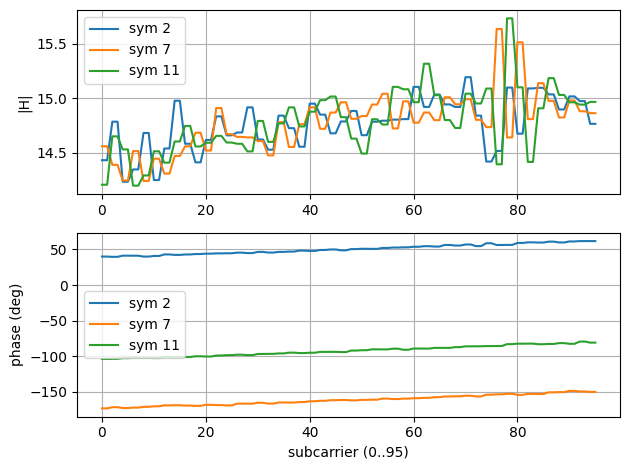

In [56]:
# PDSCH channel estimation, step 1: LS at the 3 pilot symbols
# Pilots on even SCs (comb dist 2) -> nearest-neighbour copy in freq.
# Output: H_anchor (3, 96) - one channel snapshot per DM-RS symbol.

H_anchor = np.zeros((3, 96), dtype=complex)
for i, s in enumerate(dmrs_syms):
    r = pdsch_dmrs_seq(PCI, n_slot, s, 48)
    H_pilot = Yp[s-2][dmrs_idx_p] * np.conj(r)           # LS at the comb
    for kk in range(96):                                  # nearest-neighbour in freq
        H_anchor[i, kk] = H_pilot[np.argmin(np.abs(dmrs_idx_p - kk))]

# --- inspect the 3 snapshots: |H| and phase vs subcarrier ---
fig, ax = plt.subplots(2, 1)
for i, s in enumerate(dmrs_syms):
    ax[0].plot(np.abs(H_anchor[i]), label=f'sym {s}')
    ax[1].plot(np.degrees(np.angle(H_anchor[i])), label=f'sym {s}')
ax[0].set_ylabel('|H|'); ax[1].set_ylabel('phase (deg)')
ax[1].set_xlabel('subcarrier (0..95)')
for a in ax: a.grid(); a.legend()
plt.tight_layout(); plt.show()

median step = -72.8 deg/symbol (expect ~ -72.7)


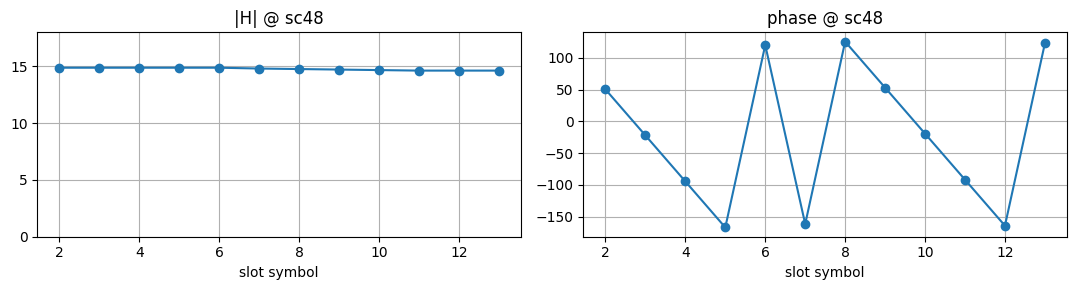

In [57]:
# Time interpolation, per-symbol phase WALK.
#
# Model: the channel phase advances by a constant step s per symbol
# (measured -72.7 deg on the adjacent PDCCH pair), EXCEPT at the
# 6->7 boundary where the long CP (4 extra samples at fc) adds a
# known extra rotation. Therefore:
#   - step s is measured ONLY on the clean 7->11 segment
#     (4 normal-CP boundaries), using the prior to fix the wrap count;
#   - symbols 3..6 walk FORWARD from anchor 2 (all their boundaries
#     are normal); the anomalous 6->7 boundary is never bridged,
#     because symbol 7 is itself an anchor;
#   - symbols 8..10 walk from anchor 7; 12..13 walk from anchor 11.
# Magnitude: linear between anchors (flat anyway).

phi = np.angle(H_anchor)                    # (3, 96)
mag = np.abs(H_anchor)

prior = np.angle(np.sum(Hc[1] * np.conj(Hc[0])))     # phase step borrowed from: PDCCH sym0->sym1
app = phi[2] - phi[1]                       # apparent 7->11 difference (96,)
k = np.round((prior*4 - app) / (2*np.pi))   # wrap count nearest the prior
s = (app + 2*np.pi*k) / 4                   # true per-symbol step (96,)

Hp = np.zeros((12, 96), dtype=complex)
for row, l in enumerate(range(2, 14)):
    if l < 7:                               # symbols 3..6: walk from anchor 2
        m = mag[0];       p = phi[0] + s*(l-2)
    elif l <= 11:                           # symbols 8..10: walk from anchor 7
        w = (l-7)/4
        m = (1-w)*mag[1] + w*mag[2]
        p = phi[1] + s*(l-7)
    else:                                   # symbols 12,13: walk from anchor 11
        m = mag[2];       p = phi[2] + s*(l-11)
    Hp[row] = m * np.exp(1j*p)

print('median step = {:+.1f} deg/symbol (expect ~ -72.7)'.format(
    np.degrees(np.median(s))))

# --- sanity ---
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(range(2,14), np.abs(Hp[:, 48]), 'o-'); ax[0].set_ylim(0, 18)
ax[1].plot(range(2,14), np.degrees(np.angle(Hp[:, 48])), 'o-')
for a_, t in zip(ax, ["|H| @ sc48", "phase @ sc48"]):
    a_.set_xlabel('slot symbol'); a_.set_title(t); a_.grid()
plt.tight_layout(); plt.show()

### The 6→7 phase anomaly: why one boundary rotates −282° instead of −73°

**The phase clock.** Our receiver never undid the TX-side NR phase
compensation (nor the integer-bin shift), so the estimated channel carries a
deterministic rotation that advances at a constant *rate* per sample. Measured
across three independent places (PBCH symbols, the adjacent PDCCH pair, the
PDSCH anchors 7→11), the per-**symbol** step is

$$\Delta\varphi_{\text{normal}} \approx -72.7^\circ \quad (\text{per } 548\text{-sample symbol})$$

**Rate is constant; step size is not.** The rotation per boundary =
rate × (samples between the two symbols' useful parts). Slot-symbols 0 and 7
carry the long CP (40 instead of 36), so the 6→7 boundary spans
**552 samples, 4 more than usual**. Those 4 extra samples at the carrier-
related rate add ≈ **−209°**:

$$\Delta\varphi_{6\to7} = \underbrace{-73^\circ}_{548\text{ samples}}
\underbrace{-209^\circ}_{4\text{ extra samples}} \approx -282^\circ$$

**Measured confirmation** (plan B sanity plot): symbol 6 sits at +120°
(walked from anchor 2 with clean −73° steps), anchor 7 measures −162° —
their gap is exactly **−282°**, without this boundary ever being modeled
explicitly. Two independently built paths meet with the anomaly's exact
shape: model and data lock.

**Why do 4 samples cost −209°?** The rotation comes from the mismatch between
the TX phase reference and our receiver: srsRAN applies the NR "phase
compensation" $e^{-j2\pi f_c t}$ per symbol at TX (ts 38.211 §5.4), referenced
to the carrier $f_c = 1876.954$ MHz, and we never undo it. Per sample of
delay, this reference rotates by

$$\frac{f_c}{F_s} = \frac{1876.954\ \text{MHz}}{7.68\ \text{MHz}}
= 244.395\ \text{cycles/sample} \;\equiv\; 0.395\ \text{cycles/sample (mod 1)}$$

Four extra samples therefore rotate

$$4 \times 0.395 = 1.579\ \text{cycles} \;\equiv\; 0.579\ \text{cycles}
\approx \mathbf{-209^\circ} \ (\text{mod } 360^\circ,\ \text{negative direction}).$$

864 QPSK symbols


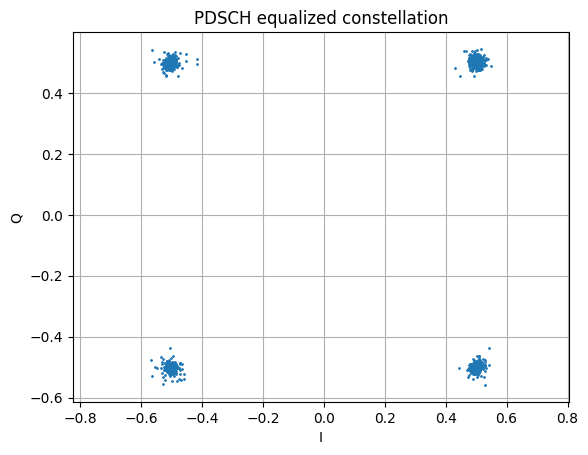

In [58]:
# ---- equalize the 9 data symbols & serialize (freq-first per symbol) ----
X_pdsch = []
data_rows = [l-2 for l in range(2,14) if l not in (2,7,11)]   # skip DM-RS symbols
for row in data_rows:
    X_pdsch.append(Yp[row] / Hp[row])
X_pdsch = np.concatenate(X_pdsch)
print(len(X_pdsch), 'QPSK symbols')                           # expect 864

plt.plot(X_pdsch.real, X_pdsch.imag, '.', markersize=2)
plt.grid(); plt.axis('equal'); plt.xlabel('I'); plt.ylabel('Q')
plt.title('PDSCH equalized constellation')
plt.show()

#### demod

In [59]:
llr_pdsch = np.zeros(2 * len(X_pdsch))
llr_pdsch[0::2] = X_pdsch.real
llr_pdsch[1::2] = X_pdsch.imag

#### descrambling

In [60]:
c_init_pdsch = (0xFFFF * 2**15 + 0 * 2**14 + PCI) % 2**31
c_ps = c_sequence(c_init_pdsch, len(llr_pdsch))       # 1728 bits
llr_ps = llr_pdsch * (1 - 2*c_ps)

#### de-rate-matching

In [61]:
# LDPC rate recovery (ts 38.212 §5.4.2, reverse), RV=0, BG2
#
# Step 1 - undo BIT INTERLEAVING (§5.4.2.2): TX interleaved the
#   E bits with Q_m = 2 rows: f[i + j*Qm] = e[i*(E/Qm) + j]
#   => even positions carry e[0:864], odd carry e[864:1728]
#   (Daniel-confirmed: "first half -> real part, second half -> imag").
#
# Step 2 - rebuild the 3744-position LLR array (Zc = 72, TBS = 640).
#   Codeword layout:
#   [0:144]      punctured head (2*Zc systematic) -> never sent -> LLR 0
#   [144:656]    systematic, transmitted          -> measured (512)
#   [656:720]    filler bits (64), known zeros    -> LLR +BIG
#   [720:1936]   parity, transmitted              -> measured (1216)
#   [1936:3744]  parity, not transmitted (RV0)    -> LLR 0

Zc     = 72
N_code = 3744                              # 52 * Zc
K_sys  = 720                               # 10 * Zc
n_head = 2 * Zc                            # 144 punctured systematic
n_fill = 64                                # K - K' = 720 - 656

# --- step 1: de-interleave (Qm = 2) ---
llr_e = np.concatenate([llr_ps[0::2], llr_ps[1::2]])   # f -> e

# --- step 2: fill the codeword-domain LLR array ---
llr_code = np.zeros(N_code)
llr_code[n_head : K_sys - n_fill] = llr_e[:512]        # systematic 144..656
llr_code[K_sys - n_fill : K_sys]  = 1e6                # fillers 656..720
llr_code[K_sys : K_sys + 1216]    = llr_e[512:]        # parity 720..1936

print('nonzero LLR positions:', np.count_nonzero(llr_code), '(expect 1792)')
print('  systematic measured:', np.count_nonzero(llr_code[144:656]))   # 512
print('  fillers (+inf):     ', np.count_nonzero(llr_code[656:720]))   # 64
print('  parity measured:    ', np.count_nonzero(llr_code[720:1936]))  # 1216

nonzero LLR positions: 1792 (expect 1792)
  systematic measured: 512
  fillers (+inf):      64
  parity measured:     1216


#### pdch decoding

### Which column of Table 5.3.2-3? — the lifting-set index i_LS

**The rule** (ts 38.212 §5.3.2, Table 5.3.2-1): the 51 legal lifting sizes
are partitioned into 8 families by writing Z = a · 2^j with a odd:

| i_LS | a | set of Z |
|---|---|---|
| 0 | 2 | {2, 4, 8, 16, 32, 64, 128, 256} |
| 1 | 3 | {3, 6, 12, 24, 48, 96, 192, 384} |
| 2 | 5 | {5, 10, 20, 40, 80, 160, 320} |
| 3 | 7 | {7, 14, 28, 56, 112, 224} |
| **4** | **9** | **{9, 18, 36, 72, 144, 288}** ← ours (Z_c = 72) |
| 5 | 11 | {11, 22, 44, 88, 176, 352} |
| 6 | 13 | {13, 26, 52, 104, 208} |
| 7 | 15 | {15, 30, 60, 120, 240} |

(Each row = one odd seed doubled until ≤ 384; the families tile all legal Z
without overlap. Recipe: strip factors of 2 from Z until odd → that odd
number's rank in {2,3,5,7,9,11,13,15} is i_LS.)

**Our case**: TBS = 640 (N_RE counts ONLY the 9 data symbols: 9·8·12 = 864 —
DM-RS symbols are excluded entirely, both combs, per the CDM-groups-without-
data rule) ⟹ B = 656 ⟹ Z_c = smallest legal Z with 10·Z ≥ 656 ⟹
**Z_c = 72** = 9 · 2³ ⟹ a = 9 ⟹ **i_LS = 4**.
All parameters verified against Daniel's PDSCH post: Z_c = 72, K = 720,
(N, K) = (3600, 720), 64 fillers, head puncture 2Z_c = 144.

In [62]:
# ts 38.212 Table 5.3.2-3 (BG2), column iLS=4
# (Zc = 72 = 9*2^3, lifting set 4 = {9, 18, 36, 72, 144, 288})
# TBS=640 -> B=656 -> Kb=10 -> Zc=72 (Daniel-verified), K=720
# source: py3gpp codes/bg2.csv; certified: H(this table, Zc=72)
# x py3gpp-encoded codeword (K'=656+64 fillers) = 0

BG2_i4 = [
(0,0,3),(0,1,26),(0,2,53),(0,3,35),(0,6,115),(0,9,127),(0,10,0),(0,11,0),
(1,0,19),(1,3,94),(1,4,104),(1,5,66),(1,6,84),(1,7,98),(1,8,69),(1,9,50),
(1,11,0),(1,12,0),(2,0,95),(2,1,106),(2,3,92),(2,4,110),(2,8,111),(2,10,1),
(2,12,0),(2,13,0),(3,1,120),(3,2,121),(3,4,22),(3,5,4),(3,6,73),(3,7,49),
(3,8,128),(3,9,79),(3,10,0),(3,13,0),(4,0,42),(4,1,24),(4,11,51),(4,14,0),
(5,0,40),(5,1,140),(5,5,84),(5,7,137),(5,11,71),(5,15,0),(6,0,109),(6,5,87),
(6,7,107),(6,9,133),(6,11,139),(6,16,0),(7,1,97),(7,5,135),(7,7,35),
(7,11,108),(7,13,65),(7,17,0),(8,0,70),(8,1,69),(8,12,88),(8,18,0),(9,1,97),
(9,8,40),(9,10,24),(9,11,49),(9,19,0),(10,0,46),(10,1,41),(10,6,101),
(10,7,96),(10,20,0),(11,0,28),(11,7,30),(11,9,116),(11,13,64),(11,21,0),
(12,1,33),(12,3,122),(12,11,131),(12,22,0),(13,0,76),(13,1,37),(13,8,62),
(13,13,47),(13,23,0),(14,1,143),(14,6,51),(14,11,130),(14,13,97),(14,24,0),
(15,0,139),(15,10,96),(15,11,128),(15,25,0),(16,1,48),(16,9,9),(16,11,28),
(16,12,8),(16,26,0),(17,1,120),(17,5,43),(17,11,65),(17,12,42),(17,27,0),
(18,0,17),(18,6,106),(18,7,142),(18,28,0),(19,0,79),(19,1,28),(19,10,41),
(19,29,0),(20,1,2),(20,4,103),(20,11,78),(20,30,0),(21,0,91),(21,8,75),
(21,13,81),(21,31,0),(22,1,54),(22,2,132),(22,32,0),(23,0,68),(23,3,115),
(23,5,56),(23,33,0),(24,1,30),(24,2,42),(24,9,101),(24,34,0),(25,0,128),
(25,5,63),(25,35,0),(26,2,142),(26,7,28),(26,12,100),(26,13,133),(26,36,0),
(27,0,13),(27,6,10),(27,37,0),(28,1,106),(28,2,77),(28,5,43),(28,38,0),
(29,0,133),(29,4,25),(29,39,0),(30,2,87),(30,5,56),(30,7,104),(30,9,70),
(30,40,0),(31,1,80),(31,13,139),(31,41,0),(32,0,32),(32,5,89),(32,12,71),
(32,42,0),(33,2,135),(33,7,6),(33,10,2),(33,43,0),(34,0,37),(34,12,25),
(34,13,114),(34,44,0),(35,1,60),(35,5,137),(35,11,93),(35,45,0),(36,0,121),
(36,2,129),(36,7,26),(36,46,0),(37,10,97),(37,13,56),(37,47,0),(38,1,1),
(38,5,70),(38,11,1),(38,48,0),(39,0,119),(39,7,32),(39,12,142),(39,49,0),
(40,2,6),(40,10,73),(40,13,102),(40,50,0),(41,1,48),(41,5,47),(41,11,19),
(41,51,0),
]
assert len(BG2_i4) == 197
assert {i for i,_,_ in BG2_i4} == set(range(42))
assert max(j for _,j,_ in BG2_i4) == 51
assert BG2_i4[0] == (0,0,3)        # spot-check vs your PDF, iLS=4 column
print('BG2 table OK (iLS=4): 197 records')

BG2 table OK (iLS=4): 197 records


In [63]:
# Lift BG2 -> equation rosters, and build an LDPC ENCODER.
# Lifting (certified): daughter equation k of super-row i
# contains bit  j*Zc + (k+s) % Zc,  s = V mod Zc.
# Encoder: H = [Hs | Hp]; parity p solves Hp*p = Hs*s over GF(2).
# Hp^-1*Hs is precomputed once by GF(2) Gaussian elimination.

n_chk, n_var, K_sys = 42*Zc, 52*Zc, 10*Zc           # 3024, 3744, 720

check_members = [[] for _ in range(n_chk)]
for (i, j, V) in BG2_i4:                            # <- iLS=4 table
    s = V % Zc
    for k in range(Zc):
        check_members[i*Zc + k].append(j*Zc + (k + s) % Zc)
check_members = [np.array(m) for m in check_members]

H = np.zeros((n_chk, n_var), dtype=np.uint8)
for c, m in enumerate(check_members):
    H[c, m] = 1

# precompute Hp^-1 * Hs by eliminating [Hp | Hs]
A = np.concatenate([H[:, K_sys:].copy(), H[:, :K_sys].copy()], axis=1)
for col in range(n_chk):
    piv = col + np.argmax(A[col:, col])
    assert A[piv, col] == 1, 'Hp singular - table/convention broken'
    if piv != col: A[[col, piv]] = A[[piv, col]]
    mask = A[:, col].copy(); mask[col] = 0
    A[mask == 1] ^= A[col]
HpinvHs = A[:, n_chk:]                              # (3024, 720)

def ldpc_encode(sys_bits):
    """720 systematic bits -> 3744-bit codeword [sys | parity]."""
    parity = (HpinvHs @ np.asarray(sys_bits)) % 2
    return np.concatenate([np.asarray(sys_bits), parity]).astype(int)

print('rosters + encoder ready;',
      'edges =', sum(len(m) for m in check_members))

rosters + encoder ready; edges = 14184


In [64]:
# LDPC DECODER: normalized min-sum, flooding schedule.
# Self-test: encode a random payload, emulate the REAL reception
# (head 144 -> LLR 0, fillers 64 -> +inf, tail -> 0, only 1728
# positions "measured"), decode, compare.

def ldpc_decode(llr_ch, members, max_iter=25, alpha=0.75):
    M = [np.zeros(len(m)) for m in members]
    for it in range(1, max_iter+1):
        total = llr_ch.copy()
        for c in range(len(members)):
            total[members[c]] += M[c]
        for c in range(len(members)):
            v2c = total[members[c]] - M[c]
            sgn = np.where(v2c < 0, -1.0, 1.0)
            mag = np.abs(v2c)
            i1 = np.argmin(mag); m1 = mag[i1]
            m2 = np.min(np.delete(mag, i1))
            out = np.full(len(mag), m1); out[i1] = m2
            M[c] = alpha * np.prod(sgn) * sgn * out
        total = llr_ch.copy()
        for c in range(len(members)):
            total[members[c]] += M[c]
        xhat = (total < 0).astype(int)
        if all(xhat[m].sum() % 2 == 0 for m in members):
            return xhat, it, True
    return xhat, max_iter, False

# ---- loopback self-test (Zc = 72 layout) ----
rng = np.random.default_rng(7)
sys720 = np.concatenate([rng.integers(0, 2, 656), np.zeros(64, int)])   # 64 fillers
cw = ldpc_encode(sys720)
assert all(cw[m].sum() % 2 == 0 for m in check_members)     # valid codeword

llr_t = np.zeros(n_var)
llr_t[144:656]  = (1 - 2*cw[144:656])  * 4.0     # systematic sent (512)
llr_t[656:720]  = 1e6                            # fillers: known zeros
llr_t[720:1936] = (1 - 2*cw[720:1936]) * 4.0     # parity measured (1216)
x_t, it_t, ok_t = ldpc_decode(llr_t, check_members)
print('self-test: converged =', ok_t, ' iter =', it_t)
print('  payload match      =', np.array_equal(x_t[:656], sys720[:656]))
print('  head-144 recovered =', np.array_equal(x_t[:144], cw[:144]))

self-test: converged = True  iter = 2
  payload match      = True
  head-144 recovered = True


In [65]:
xhat, n_iter, ok = ldpc_decode(llr_code, check_members)
print('converged:', ok, ' at iteration', n_iter)

converged: True  at iteration 2


#### crc

In [66]:
# Transport block CRC16 (ts 38.212 §5.1: g(D)=D^16+D^12+D^5+1,
# zeros-init, no mask) over the 640-bit payload.  Zc=72 layout:
# sysbits = xhat[:720] = [640 payload | 16 CRC | 64 fillers]

def crc16(bits):
    poly, reg = 0x11021, 0
    for b in bits:
        reg = ((reg << 1) | int(b)) & 0x1FFFF
        if reg >> 16: reg ^= poly
    for _ in range(16):
        reg = (reg << 1) & 0x1FFFF
        if reg >> 16: reg ^= poly
    return np.array([(reg >> (15-i)) & 1 for i in range(16)])

sysbits = xhat[:720]
payload, crc_rx = sysbits[:640], sysbits[640:656]
print('fillers decoded as zero:', np.array_equal(sysbits[656:720], np.zeros(64, int)))
print('TB CRC16:', 'PASS' if np.array_equal(crc16(payload), crc_rx) else 'FAIL')

fillers decoded as zero: True
TB CRC16: PASS


#### read SIB1

In [67]:
from pycrate_asn1dir import RRCNR          # pip install pycrate

tb_bytes = bytes(np.packbits(payload))     # 640 bit -> 80 bytes
print('TB hex:', tb_bytes.hex())

msg = RRCNR.NR_RRC_Definitions.BCCH_DL_SCH_Message
msg.from_uper(tb_bytes)
print(msg.to_asn1())

TB hex: 748101701040040200000e000003361805410040020000030c339021b3704020000080800041a0352426080215ba080000061c3390240010080cc9461c00938441befd5b1c3a802b16d1850000000000
{
  message c1 : systemInformationBlockType1 : {
    cellSelectionInfo {
      q-RxLevMin -70,
      q-QualMin -20
    },
    cellAccessRelatedInfo {
      plmn-IdentityInfoList {
        {
          plmn-IdentityList {
            {
              mcc {
                0,
                0,
                1
              },
              mnc {
                0,
                1
              }
            }
          },
          trackingAreaCode '000007'H,
          cellIdentity '0000019B0'H,
          cellReservedForOperatorUse notReserved
        }
      }
    },
    connEstFailureControl {
      connEstFailCount n1,
      connEstFailOffsetValidity s30,
      connEstFailOffset 1
    },
    servingCellConfigCommon {
      downlinkConfigCommon {
        frequencyInfoDL {
          frequencyBandList {
            {
 